In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import os
from collections import Counter

# --- 环境设置 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_dir = os.path.join(os.getcwd(), 'sleep-edf', 'data')
model_save_path = os.path.join(data_dir, 'model', 'model011701.pth')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# --- 超参数 ---
batch_size = 64
lr = 5e-4
num_epochs = 50
num_classes = 4

# --- 1. 核心逻辑：按患者构建时序数据（5-Epoch 窗口）---
def load_context_data(root_path, window_size=5):
    """
    遍历 patient_data 文件夹，构建 5-Epoch 窗口：(t-2, t-1, t, t+1, t+2)
    """
    patient_dir = os.path.join(root_path, 'patient_data')
    X_all, y_all = [], []
    
    if not os.path.exists(patient_dir):
        raise FileNotFoundError(f"找不到路径: {patient_dir}")

    x_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('_X.npy')])
    
    print(f"Loading patients from {patient_dir}...")
    half_window = window_size // 2
    for f in tqdm(x_files):
        patient_id = f.replace('_X.npy', '')
        x_sub = np.load(os.path.join(patient_dir, f))
        y_sub = np.load(os.path.join(patient_dir, f"{patient_id}_y.npy"))
        
        # 标签清理与映射
        valid = (y_sub != -1)
        x_sub, y_sub = x_sub[valid], y_sub[valid]
        
        y_mapped = np.zeros_like(y_sub)
        y_mapped[y_sub == 0] = 0  # W
        y_mapped[y_sub == 4] = 1  # REM
        y_mapped[(y_sub == 1) | (y_sub == 2)] = 2  # Light (N1+N2)
        y_mapped[y_sub == 3] = 3  # Deep (N3)
        
        # 构建 5-Epoch 窗口
        for i in range(half_window, len(x_sub) - half_window):
            window = x_sub[i - half_window: i + half_window + 1]  # (5, 3000)
            X_all.append(window)
            y_all.append(y_mapped[i])
            
    return np.array(X_all), np.array(y_all)

# --- 2. 数据集类（增强增广：噪声 + 随机遮罩，移除时间拉伸）---
class SleepContextDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32).float()  # 确保 float
        self.y = torch.tensor(y, dtype=torch.long)
        
        # 全局标准化
        mean, std = self.X.mean(), self.X.std()
        self.X = (self.X - mean) / (std + 1e-6)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        
        if self.augment and x.is_floating_point():
            # 原增强：微小噪声
            if torch.rand(1) < 0.3:
                x = x + torch.randn_like(x) * 0.005
            # 保留：随机遮罩（10% 信号丢失）
            if torch.rand(1) < 0.25:
                mask = torch.rand_like(x) > 0.1  # 适用于 float
                x = x * mask
        
        return x, y

# --- 3. 模型（5通道输入）---
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ELU(),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se = SEBlock(out_ch) # 新增注意力
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        self.elu = nn.ELU()

    def forward(self, x):
        out = self.conv(x)
        out = self.se(out) # 赋予特征通道权重
        return self.elu(out + self.shortcut(x))

class SleepStageNetV7(nn.Module):
    def __init__(self, num_classes, window_size=15): # 建议 window_size 设为 15
        super().__init__()
        self.n_fft = 512
        self.hop_length = 64
        self.window_size = window_size
        
        # --- 优化点 B: 多尺度特征提取 (Multi-scale Stem) ---
        # 使用不同大小的卷积核同时捕获精细波形和宏观频率
        self.stem_small = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.stem_large = nn.Conv2d(1, 16, kernel_size=7, stride=1, padding=3, bias=False)
        self.stem_bn = nn.BatchNorm2d(32)
        self.stem_elu = nn.ELU()
        
        # --- 特征提取骨架 ---
        self.stage1 = ResBlock(32, 64, stride=2)
        self.stage2 = ResBlock(64, 128, stride=2)
        self.stage3 = ResBlock(128, 256, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # --- 优化点 A & C: Transformer 增强长时序依赖 ---
        # 每个 Epoch 提取 256 维特征
        self.feature_dim = 256
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.feature_dim, 
            nhead=8, 
            dim_feedforward=512, 
            dropout=0.3,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        # 用于聚合所有 Epoch 信息预测中间那个 Epoch 的分类器
        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # 输入形状是 [Batch, 15, 1, 3001]
        # 将其展平为 [Batch * 15, 3001] 以便进行 STFT
        
        # 1. 自动处理维度转换
        if x.dim() == 4:
            # 去掉为 1 的维度 (Channel)，形状变为 [64, 15, 3001]
            x = x.squeeze(2) 
        
        b, t, s = x.shape  # 现在这里不再报错，b=64, t=15, s=3001
        
        # --- 1. STFT 转换为频谱图 ---
        # 展平前两维，把所有 Epoch 堆叠在一起并行计算
        x_flat = x.reshape(b * t, s) 
        
        win = torch.hann_window(self.n_fft).to(x.device)
        stft = torch.stft(x_flat, n_fft=self.n_fft, hop_length=self.hop_length, 
                          window=win, return_complex=True, center=True)
        
        # 获取幅值谱，并截取前128个频率分量
        mag = (torch.abs(stft) + 1e-8).log()
        mag = mag[:, :128, :].unsqueeze(1) # 增加通道维，形状: [B*T, 1, 128, Seq]
        
        # --- 2. CNN 特征提取 (共享权重) ---
        x1 = self.stem_small(mag)
        x2 = self.stem_large(mag)
        feat = self.stem_elu(self.stem_bn(torch.cat([x1, x2], dim=1)))
        
        feat = self.stage1(feat)
        feat = self.stage2(feat)
        feat = self.stage3(feat)
        feat = self.avgpool(feat).flatten(1) # [B*T, 256]
        
        # --- 3. 序列建模 (Transformer) ---
        # 恢复序列形状: [Batch, Window_Size, 256]
        feat = feat.view(b, t, self.feature_dim)
        seq_feat = self.transformer(feat) 
        
        # 取时间窗口中心的那个 Epoch 对应的特征进行分类
        mid_idx = t // 2
        final_feat = seq_feat[:, mid_idx, :]
        
        # --- 4. 分类器 ---
        return self.classifier(final_feat)



# --- 4. 评估 ---
def evaluate(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x.to(device))
            all_p.extend(outputs.argmax(1).cpu().numpy())
            all_l.extend(y.numpy())
    return accuracy_score(all_l, all_p), f1_score(all_l, all_p, average='macro'), Counter(all_p)

# --- 5. 主训练程序 ---
if __name__ == "__main__":
    window_size = 10
    train_X, train_y = load_context_data(os.path.join(data_dir, 'train', 'cache'), window_size=window_size)
    val_X, val_y = load_context_data(os.path.join(data_dir, 'val', 'cache'), window_size=window_size)
    
    train_loader = DataLoader(SleepContextDataset(train_X, train_y, augment=True), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SleepContextDataset(val_X, val_y), batch_size=batch_size)

    model = SleepStageNetV7(num_classes=num_classes, window_size=window_size).to(device)
    
    cls_weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
    cls_weights = torch.tensor(cls_weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=cls_weights, label_smoothing=0.1)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    
    best_acc = 0
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=total_loss / len(pbar))
        
        acc, f1, preds_counter = evaluate(model, val_loader)
        print(f"Val Acc: {acc:.4f} | F1: {f1:.4f} | Dist: {preds_counter}")
        
        scheduler.step()
        
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), model_save_path)
            print(f">>> New Best Model Saved (Acc: {best_acc:.4f})")

    print(f"Final Best Val Accuracy: {best_acc:.4f}")


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\train\cache\patient_data...


100%|██████████| 122/122 [00:00<00:00, 383.36it/s]


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\val\cache\patient_data...


Epoch 1: 100%|██████████| 158/158 [02:57<00:00,  1.12s/it, loss=1.26] 


Val Acc: 0.3426 | F1: 0.3657 | Dist: Counter({np.int64(3): 495, np.int64(1): 336, np.int64(0): 238, np.int64(2): 119})
>>> New Best Model Saved (Acc: 0.3426)


...

Val Acc: 0.4091 | F1: 0.4437 | Dist: Counter({np.int64(0): 411, np.int64(1): 345, np.int64(3): 304, np.int64(2): 128})
>>> New Best Model Saved (Acc: 0.4091)


Epoch 3: 100%|██████████| 158/158 [02:56<00:00,  1.12s/it, loss=1.09] 


Val Acc: 0.3342 | F1: 0.3919 | Dist: Counter({np.int64(1): 519, np.int64(0): 387, np.int64(3): 244, np.int64(2): 38})


Epoch 4:   7%|▋         | 11/158 [00:13<03:00,  1.23s/it, loss=0.0722]


KeyboardInterrupt: 

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import os
from collections import Counter

# --- 环境设置 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_dir = os.path.join(os.getcwd(), 'sleep-edf', 'data')
model_save_path = os.path.join(data_dir, 'model', 'model011801.pth')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# --- 超参数 ---
batch_size = 64
lr = 1e-3
num_epochs = 200
num_classes = 4

# --- 1. 核心逻辑：按患者构建时序数据（5-Epoch 窗口）---
def load_context_data(root_path, window_size=5):
    """
    遍历 patient_data 文件夹，构建 5-Epoch 窗口：(t-2, t-1, t, t+1, t+2)
    """
    patient_dir = os.path.join(root_path, 'patient_data')
    X_all, y_all = [], []
    
    if not os.path.exists(patient_dir):
        raise FileNotFoundError(f"找不到路径: {patient_dir}")

    x_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('_X.npy')])
    
    print(f"Loading patients from {patient_dir}...")
    half_window = window_size // 2
    for f in tqdm(x_files):
        patient_id = f.replace('_X.npy', '')
        x_sub = np.load(os.path.join(patient_dir, f))
        y_sub = np.load(os.path.join(patient_dir, f"{patient_id}_y.npy"))
        
        # 标签清理与映射
        valid = (y_sub != -1)
        x_sub, y_sub = x_sub[valid], y_sub[valid]
        
        y_mapped = np.zeros_like(y_sub)
        y_mapped[y_sub == 0] = 0  # W
        y_mapped[y_sub == 4] = 1  # REM
        y_mapped[(y_sub == 1) | (y_sub == 2)] = 2  # Light (N1+N2)
        y_mapped[y_sub == 3] = 3  # Deep (N3)
        
        # 构建 5-Epoch 窗口
        for i in range(half_window, len(x_sub) - half_window):
            window = x_sub[i - half_window: i + half_window + 1]  # (5, 3000)
            X_all.append(window)
            y_all.append(y_mapped[i])
            
    return np.array(X_all), np.array(y_all)

# --- 2. 数据集类（增强增广：噪声 + 随机遮罩，移除时间拉伸）---
class SleepContextDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32).float()  # 确保 float
        self.y = torch.tensor(y, dtype=torch.long)
        
        # 全局标准化
        mean, std = self.X.mean(), self.X.std()
        self.X = (self.X - mean) / (std + 1e-6)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        
        if self.augment and x.is_floating_point():
            # 原增强：微小噪声
            if torch.rand(1) < 0.3:
                x = x + torch.randn_like(x) * 0.005
            # 保留：随机遮罩（10% 信号丢失）
            if torch.rand(1) < 0.25:
                mask = torch.rand_like(x) > 0.1  # 适用于 float
                x = x * mask
        
        return x, y

# --- 3. 模型（5通道输入）---
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ELU(),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se = SEBlock(out_ch) # 新增注意力
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        self.elu = nn.ELU()

    def forward(self, x):
        out = self.conv(x)
        out = self.se(out) # 赋予特征通道权重
        return self.elu(out + self.shortcut(x))


class SleepStageNetV6(nn.Module):
    def __init__(self, num_classes, input_channels=5):
        super().__init__()
        self.n_fft = 512
        self.hop_length = 64
        
        # 输入调整为5通道
        self.stem = nn.Sequential(
            nn.Conv2d(input_channels, 32, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU()
        )
        
        self.stage1 = ResBlock(32, 64, stride=2)
        self.stage2 = ResBlock(64, 128, stride=2)
        self.stage3 = ResBlock(128, 256, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # GRU
        self.rnn = nn.GRU(256, 128, num_layers=2, bidirectional=True, batch_first=True, dropout=0.3)
        
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        if x.dim() > 3:
            x = x.view(x.shape[0], 5, -1)
        b, c, s = x.shape
        win = torch.hann_window(self.n_fft).to(x.device)
        
        specs = []
        for i in range(c):
            stft = torch.stft(x[:, i, :], n_fft=self.n_fft, hop_length=self.hop_length, 
                              window=win, return_complex=True, center=True)
            mag = (torch.abs(stft) + 1e-8).log()
            mag = mag[:, :128, :]
            specs.append(mag.unsqueeze(1))
            
        x = torch.cat(specs, dim=1)
        
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        
        x = self.avgpool(x).flatten(1).unsqueeze(1)
        x, _ = self.rnn(x)
        x = x.squeeze(1)
        return self.classifier(x)

# --- 4. 评估 ---
def evaluate(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x.to(device))
            all_p.extend(outputs.argmax(1).cpu().numpy())
            all_l.extend(y.numpy())
    return accuracy_score(all_l, all_p), f1_score(all_l, all_p, average='macro'), Counter(all_p)

# --- 5. 主训练程序 ---
if __name__ == "__main__":
    window_size = 5
    train_X, train_y = load_context_data(os.path.join(data_dir, 'train', 'cache'), window_size=window_size)
    val_X, val_y = load_context_data(os.path.join(data_dir, 'val', 'cache'), window_size=window_size)
    
    train_loader = DataLoader(SleepContextDataset(train_X, train_y, augment=True), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SleepContextDataset(val_X, val_y), batch_size=batch_size)

    model = SleepStageNetV6(num_classes=num_classes, input_channels=window_size).to(device)
    
    cls_weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
    cls_weights = torch.tensor(cls_weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=cls_weights, label_smoothing=0.1)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
    
    best_acc = 0
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=total_loss / len(pbar))
        
        acc, f1, preds_counter = evaluate(model, val_loader)
        print(f"Val Acc: {acc:.4f} | F1: {f1:.4f} | Dist: {preds_counter}")
        
        scheduler.step()
        
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), model_save_path)
            print(f">>> New Best Model Saved (Acc: {best_acc:.4f})")

    print(f"Final Best Val Accuracy: {best_acc:.4f}")


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\train\cache\patient_data...


100%|██████████| 122/122 [00:00<00:00, 554.36it/s]


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\val\cache\patient_data...


Epoch 1: 100%|██████████| 169/169 [00:03<00:00, 42.92it/s, loss=1.22] 


Val Acc: 0.4272 | F1: 0.4363 | Dist: Counter({np.int64(0): 537, np.int64(3): 354, np.int64(2): 241, np.int64(1): 146})
>>> New Best Model Saved (Acc: 0.4272)


...

Val Acc: 0.7207 | F1: 0.6343 | Dist: Counter({np.int64(2): 829, np.int64(0): 173, np.int64(1): 139, np.int64(3): 137})


Epoch 199: 100%|██████████| 169/169 [00:03<00:00, 47.31it/s, loss=0.59] 


Val Acc: 0.7034 | F1: 0.5421 | Dist: Counter({np.int64(2): 991, np.int64(0): 140, np.int64(1): 78, np.int64(3): 69})


Epoch 200: 100%|██████████| 169/169 [00:03<00:00, 44.86it/s, loss=0.592]


Val Acc: 0.7355 | F1: 0.6446 | Dist: Counter({np.int64(2): 831, np.int64(0): 185, np.int64(3): 177, np.int64(1): 85})
Final Best Val Accuracy: 0.7527


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\train\cache\patient_data...


100%|██████████| 122/122 [00:00<00:00, 397.31it/s]


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\val\cache\patient_data...


Epoch 1: 100%|██████████| 169/169 [00:09<00:00, 17.77it/s, loss=1.23] 


Val Acc: 0.3709 | F1: 0.4081 | Dist: Counter({np.int64(1): 514, np.int64(3): 391, np.int64(0): 254, np.int64(2): 119})
>>> New Best Model Saved (Acc: 0.3709)


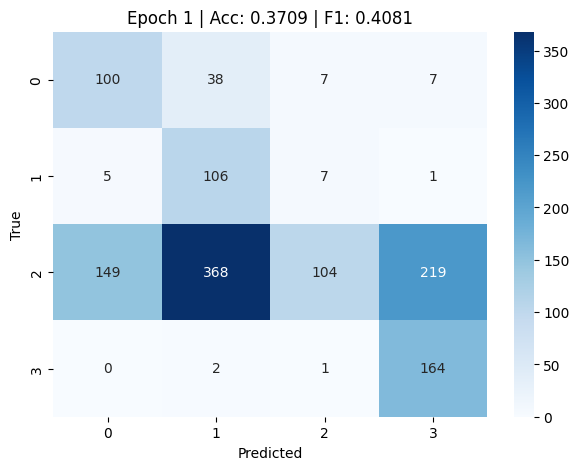

Epoch 1 | Overall Acc: 0.3709 | F1: 0.4081
Class-wise Accuracies:
  Class 0: 0.6579
  Class 1: 0.8908
  Class 2: 0.1238
  Class 3: 0.9820


Epoch 2: 100%|██████████| 169/169 [00:08<00:00, 20.71it/s, loss=1.04] 


Val Acc: 0.5125 | F1: 0.5336 | Dist: Counter({np.int64(1): 368, np.int64(0): 355, np.int64(3): 278, np.int64(2): 277})
>>> New Best Model Saved (Acc: 0.5125)


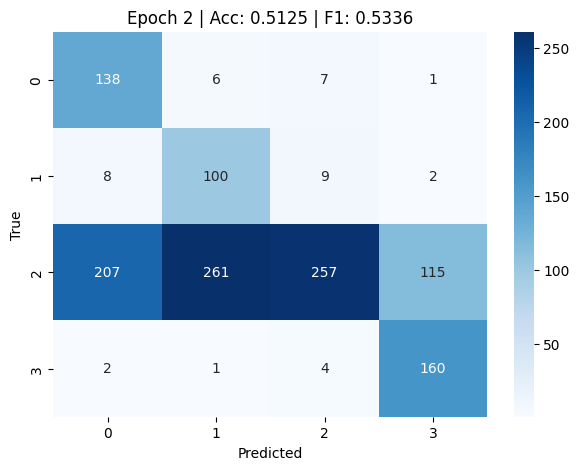

Epoch 2 | Overall Acc: 0.5125 | F1: 0.5336
Class-wise Accuracies:
  Class 0: 0.9079
  Class 1: 0.8403
  Class 2: 0.3060
  Class 3: 0.9581


Epoch 3: 100%|██████████| 169/169 [00:08<00:00, 20.65it/s, loss=0.978]


Val Acc: 0.5516 | F1: 0.5553 | Dist: Counter({np.int64(2): 359, np.int64(1): 336, np.int64(3): 332, np.int64(0): 251})
>>> New Best Model Saved (Acc: 0.5516)


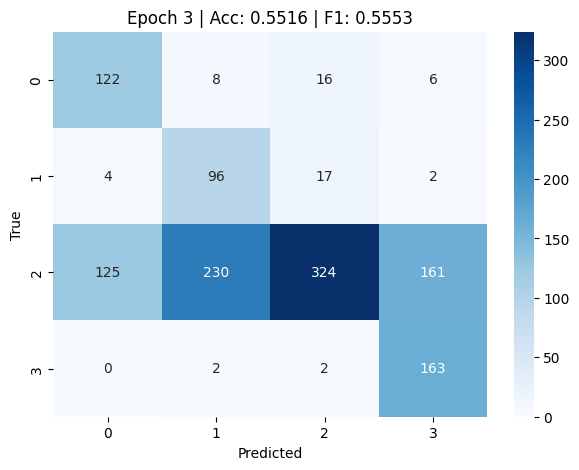

Epoch 3 | Overall Acc: 0.5516 | F1: 0.5553
Class-wise Accuracies:
  Class 0: 0.8026
  Class 1: 0.8067
  Class 2: 0.3857
  Class 3: 0.9760


Epoch 4: 100%|██████████| 169/169 [00:08<00:00, 20.63it/s, loss=0.946]


Val Acc: 0.6549 | F1: 0.6360 | Dist: Counter({np.int64(2): 603, np.int64(1): 341, np.int64(0): 168, np.int64(3): 166})
>>> New Best Model Saved (Acc: 0.6549)


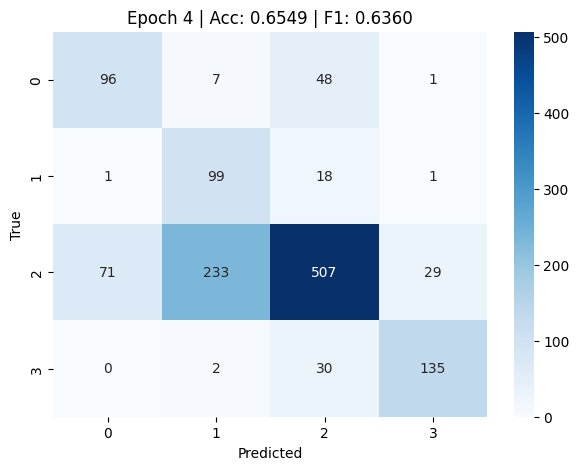

Epoch 4 | Overall Acc: 0.6549 | F1: 0.6360
Class-wise Accuracies:
  Class 0: 0.6316
  Class 1: 0.8319
  Class 2: 0.6036
  Class 3: 0.8084


Epoch 5: 100%|██████████| 169/169 [00:08<00:00, 20.47it/s, loss=0.917]


Val Acc: 0.7191 | F1: 0.6803 | Dist: Counter({np.int64(2): 656, np.int64(1): 244, np.int64(3): 191, np.int64(0): 187})
>>> New Best Model Saved (Acc: 0.7191)


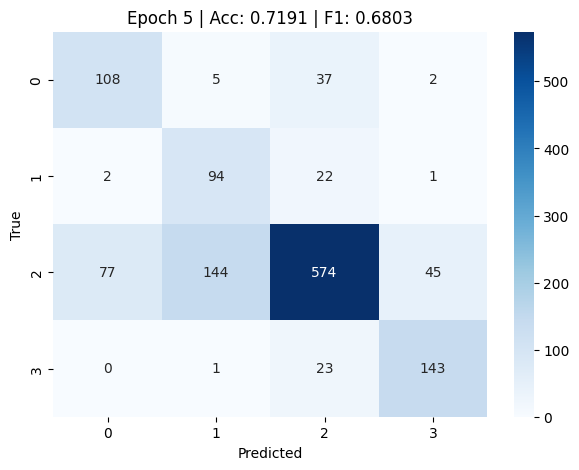

Epoch 5 | Overall Acc: 0.7191 | F1: 0.6803
Class-wise Accuracies:
  Class 0: 0.7105
  Class 1: 0.7899
  Class 2: 0.6833
  Class 3: 0.8563


Epoch 6: 100%|██████████| 169/169 [00:08<00:00, 20.37it/s, loss=0.897]


Val Acc: 0.6330 | F1: 0.6142 | Dist: Counter({np.int64(2): 472, np.int64(3): 341, np.int64(0): 261, np.int64(1): 204})


Epoch 7: 100%|██████████| 169/169 [00:08<00:00, 20.71it/s, loss=0.865]


Val Acc: 0.6808 | F1: 0.6183 | Dist: Counter({np.int64(2): 640, np.int64(3): 342, np.int64(0): 222, np.int64(1): 74})


...

Val Acc: 0.6541 | F1: 0.6201 | Dist: Counter({np.int64(2): 622, np.int64(1): 267, np.int64(0): 255, np.int64(3): 134})


Epoch 15: 100%|██████████| 169/169 [00:08<00:00, 20.33it/s, loss=0.707]


Val Acc: 0.7034 | F1: 0.6494 | Dist: Counter({np.int64(2): 698, np.int64(1): 222, np.int64(3): 191, np.int64(0): 167})


Epoch 16: 100%|██████████| 169/169 [00:08<00:00, 19.86it/s, loss=0.701]


Val Acc: 0.7457 | F1: 0.6861 | Dist: Counter({np.int64(2): 758, np.int64(1): 177, np.int64(0): 177, np.int64(3): 166})
>>> New Best Model Saved (Acc: 0.7457)


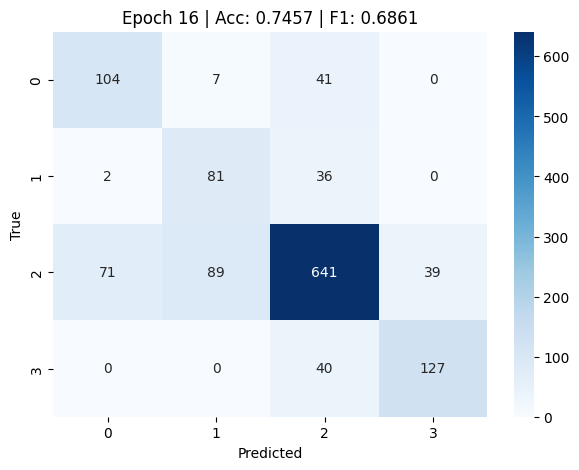

Epoch 16 | Overall Acc: 0.7457 | F1: 0.6861
Class-wise Accuracies:
  Class 0: 0.6842
  Class 1: 0.6807
  Class 2: 0.7631
  Class 3: 0.7605


Epoch 17: 100%|██████████| 169/169 [00:08<00:00, 20.43it/s, loss=0.686]


Val Acc: 0.6682 | F1: 0.6350 | Dist: Counter({np.int64(2): 633, np.int64(1): 322, np.int64(0): 163, np.int64(3): 160})


Epoch 18: 100%|██████████| 169/169 [00:08<00:00, 20.68it/s, loss=0.683]


Val Acc: 0.7293 | F1: 0.6430 | Dist: Counter({np.int64(2): 765, np.int64(3): 291, np.int64(0): 141, np.int64(1): 81})


Epoch 19: 100%|██████████| 169/169 [00:08<00:00, 20.75it/s, loss=0.666]


Val Acc: 0.7410 | F1: 0.6644 | Dist: Counter({np.int64(2): 774, np.int64(3): 224, np.int64(0): 160, np.int64(1): 120})


Epoch 20: 100%|██████████| 169/169 [00:08<00:00, 20.73it/s, loss=0.66] 


Val Acc: 0.7543 | F1: 0.6668 | Dist: Counter({np.int64(2): 823, np.int64(3): 224, np.int64(0): 146, np.int64(1): 85})
>>> New Best Model Saved (Acc: 0.7543)


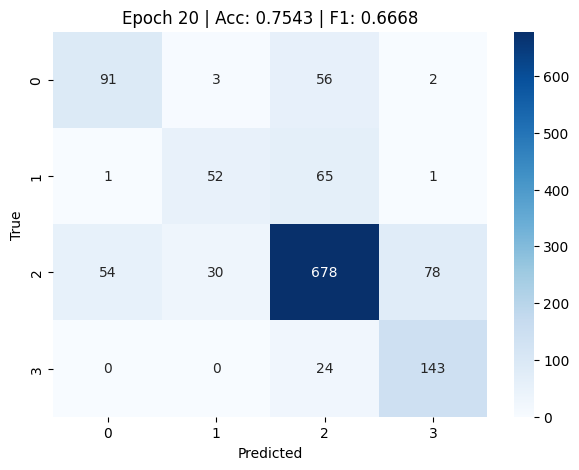

Epoch 20 | Overall Acc: 0.7543 | F1: 0.6668
Class-wise Accuracies:
  Class 0: 0.5987
  Class 1: 0.4370
  Class 2: 0.8071
  Class 3: 0.8563


Epoch 21: 100%|██████████| 169/169 [00:08<00:00, 20.41it/s, loss=0.648]


Val Acc: 0.7347 | F1: 0.6673 | Dist: Counter({np.int64(2): 766, np.int64(1): 182, np.int64(0): 168, np.int64(3): 162})


Epoch 22: 100%|██████████| 169/169 [00:08<00:00, 20.64it/s, loss=0.648]


Val Acc: 0.7786 | F1: 0.6692 | Dist: Counter({np.int64(2): 923, np.int64(3): 153, np.int64(0): 132, np.int64(1): 70})
>>> New Best Model Saved (Acc: 0.7786)


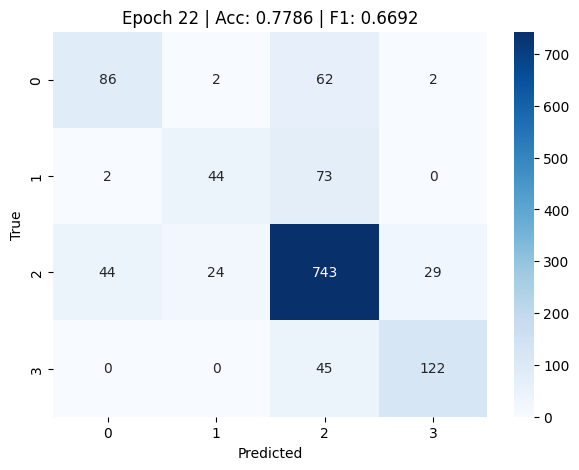

Epoch 22 | Overall Acc: 0.7786 | F1: 0.6692
Class-wise Accuracies:
  Class 0: 0.5658
  Class 1: 0.3697
  Class 2: 0.8845
  Class 3: 0.7305


Epoch 23: 100%|██████████| 169/169 [00:08<00:00, 20.76it/s, loss=0.643]


Val Acc: 0.7731 | F1: 0.6848 | Dist: Counter({np.int64(2): 847, np.int64(3): 176, np.int64(0): 171, np.int64(1): 84})


Epoch 24: 100%|██████████| 169/169 [00:08<00:00, 20.64it/s, loss=0.632]


Val Acc: 0.7371 | F1: 0.6716 | Dist: Counter({np.int64(2): 750, np.int64(0): 207, np.int64(3): 193, np.int64(1): 128})


...

Val Acc: 0.7660 | F1: 0.6805 | Dist: Counter({np.int64(2): 862, np.int64(3): 165, np.int64(0): 139, np.int64(1): 112})


Epoch 49: 100%|██████████| 169/169 [00:08<00:00, 20.54it/s, loss=0.58] 


Val Acc: 0.7660 | F1: 0.6787 | Dist: Counter({np.int64(2): 861, np.int64(3): 175, np.int64(0): 130, np.int64(1): 112})


Epoch 50: 100%|██████████| 169/169 [00:08<00:00, 20.62it/s, loss=0.584]


Val Acc: 0.7637 | F1: 0.6785 | Dist: Counter({np.int64(2): 857, np.int64(3): 170, np.int64(0): 134, np.int64(1): 117})
Final Best Val Accuracy: 0.7786


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import os
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# --- 环境设置 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_dir = os.path.join(os.getcwd(), 'sleep-edf', 'data')
model_save_path = os.path.join(data_dir, 'model', 'model011903.pth')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# --- 超参数 ---
batch_size = 64
lr = 3e-4
num_epochs = 50
num_classes = 4

# --- 1. 核心逻辑：按患者构建时序数据（5-Epoch 窗口）---
def load_context_data(root_path, window_size=5):
    """
    遍历 patient_data 文件夹，构建 5-Epoch 窗口：(t-2, t-1, t, t+1, t+2)
    """
    patient_dir = os.path.join(root_path, 'patient_data')
    X_all, y_all = [], []
    
    if not os.path.exists(patient_dir):
        raise FileNotFoundError(f"找不到路径: {patient_dir}")

    x_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('_X.npy')])
    
    print(f"Loading patients from {patient_dir}...")
    half_window = window_size // 2
    for f in tqdm(x_files):
        patient_id = f.replace('_X.npy', '')
        x_sub = np.load(os.path.join(patient_dir, f))
        y_sub = np.load(os.path.join(patient_dir, f"{patient_id}_y.npy"))
        
        # 标签清理与映射
        valid = (y_sub != -1)
        x_sub, y_sub = x_sub[valid], y_sub[valid]
        
        y_mapped = np.zeros_like(y_sub)
        y_mapped[y_sub == 0] = 0  # W
        y_mapped[y_sub == 4] = 1  # REM
        y_mapped[(y_sub == 1) | (y_sub == 2)] = 2  # Light (N1+N2)
        y_mapped[y_sub == 3] = 3  # Deep (N3)
        
        # 构建 5-Epoch 窗口
        for i in range(half_window, len(x_sub) - half_window):
            window = x_sub[i - half_window: i + half_window + 1]  # (5, 3000)
            X_all.append(window)
            y_all.append(y_mapped[i])
            
    return np.array(X_all), np.array(y_all)

# --- 2. 数据集类（增强增广：噪声 + 随机遮罩，移除时间拉伸）---
class SleepContextDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32).float()  # 确保 float
        self.y = torch.tensor(y, dtype=torch.long)
        
        # 全局标准化
        mean, std = self.X.mean(), self.X.std()
        self.X = (self.X - mean) / (std + 1e-6)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        
        if self.augment and x.is_floating_point():
            # 原增强：微小噪声
            if torch.rand(1) < 0.3:
                x = x + torch.randn_like(x) * 0.005
            # 保留：随机遮罩（10% 信号丢失）
            if torch.rand(1) < 0.25:
                mask = torch.rand_like(x) > 0.1  # 适用于 float
                x = x * mask
        
        return x, y

# --- 3. 模型（5通道输入）---
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ELU(),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se = SEBlock(out_ch) # 新增注意力
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        self.elu = nn.ELU()

    def forward(self, x):
        out = self.conv(x)
        out = self.se(out) # 赋予特征通道权重
        return self.elu(out + self.shortcut(x))


class SleepStageNetV8(nn.Module):
    def __init__(self, num_classes, window_size=5):
        super().__init__()
        self.window_size = window_size
        self.n_fft = 512
        self.hop_length = 64
        
        # --- 分支 A: 频谱特征提取 (2D CNN) ---
        self.spec_stem = nn.Sequential(
            nn.Conv2d(1, 32, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU()
        )
        self.spec_stage = nn.Sequential(
            ResBlock(32, 64, stride=2),
            ResBlock(64, 128, stride=2),
            ResBlock(128, 128, stride=2), # 缩减输出通道为128
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        # --- 分支 B: 原始波形特征提取 (1D CNN) ---
        # 模仿 TinySleepNet/DeepSleepNet 的小核+大核思想简化版
        self.raw_branch = nn.Sequential(
            # 第一层使用较大的卷积核捕捉低频节律 (如 Delta 波)
            nn.Conv1d(1, 64, kernel_size=64, stride=8, padding=32, bias=False),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.MaxPool1d(kernel_size=8, stride=8),
            # 第二层捕捉局部细节
            nn.Conv1d(64, 128, kernel_size=16, stride=1, padding=8, bias=False),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.AdaptiveAvgPool1d(1) # 输出维度 (B*T, 128, 1)
        )
        
        # --- 融合与时序层 ---
        # 两个分支各出 128 维，合起来是 256
        self.rnn = nn.GRU(128 + 128, 128, num_layers=2, bidirectional=True, batch_first=True, dropout=0.3)
        
        # 分类器
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: [Batch, 5, 1, 3001]
        b, t, c, s = x.shape
        x_flat = x.view(b * t, c, s) # [B*T, 1, 3001]
        
        # --- 1. 频谱分支 (2D) ---
        # 在 forward 内部计算频谱
        win = torch.hann_window(self.n_fft).to(x.device)
        stft = torch.stft(x_flat.squeeze(1), n_fft=self.n_fft, hop_length=self.hop_length, 
                          window=win, return_complex=True, center=True)
        mag = (torch.abs(stft) + 1e-8).log().unsqueeze(1) # [B*T, 1, F, T]
        mag = mag[:, :, :128, :] # 取低频部分
        
        spec_fea = self.spec_stem(mag)
        spec_fea = self.spec_stage(spec_fea).flatten(1) # [B*T, 128]
        
        # --- 2. 原始波形分支 (1D) ---
        raw_fea = self.raw_branch(x_flat).flatten(1) # [B*T, 128]
        
        # --- 3. 特征融合 ---
        combined_fea = torch.cat([spec_fea, raw_fea], dim=1) # [B*T, 256]
        
        # --- 4. 还原序列维度过 RNN ---
        combined_fea = combined_fea.view(b, t, -1) # [B, 5, 256]
        rnn_out, _ = self.rnn(combined_fea)  # [B, 5, 256]
        
        # --- 5. 取中间 Epoch 输出 ---
        mid_idx = t // 2
        return self.classifier(rnn_out[:, mid_idx, :])



# --- 4. 评估 ---
def evaluate(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x.to(device))
            all_p.extend(outputs.argmax(1).cpu().numpy())
            all_l.extend(y.numpy())
    return accuracy_score(all_l, all_p), f1_score(all_l, all_p, average='macro'), confusion_matrix(all_l, all_p), Counter(all_p)

def print_confusion_matrix(cm, acc, f1, epoch):
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Epoch {epoch} | Acc: {acc:.4f} | F1: {f1:.4f}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
    # 计算每个分类的准确率
    class_accuracies = cm.diagonal() / cm.sum(axis=1)
    print(f"Epoch {epoch} | Overall Acc: {acc:.4f} | F1: {f1:.4f}")
    print("Class-wise Accuracies:")
    for i, class_acc in enumerate(class_accuracies):
        print(f"  Class {i}: {class_acc:.4f}")

# --- 5. 主训练程序 ---
if __name__ == "__main__":
    window_size = 5
    train_X, train_y = load_context_data(os.path.join(data_dir, 'train', 'cache'), window_size=window_size)
    val_X, val_y = load_context_data(os.path.join(data_dir, 'val', 'cache'), window_size=window_size)
    
    train_loader = DataLoader(SleepContextDataset(train_X, train_y, augment=True), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SleepContextDataset(val_X, val_y), batch_size=batch_size)

    model = SleepStageNetV8(num_classes=num_classes, window_size=window_size).to(device)
    
    cls_weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
    cls_weights = torch.tensor(cls_weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=cls_weights, label_smoothing=0.1)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    best_acc = 0
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=total_loss / len(pbar))
        
        acc, f1, cm, preds_counter = evaluate(model, val_loader)
        print(f"Val Acc: {acc:.4f} | F1: {f1:.4f} | Dist: {preds_counter}")
        
        scheduler.step()
        
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), model_save_path)
            print(f">>> New Best Model Saved (Acc: {best_acc:.4f})")
            print_confusion_matrix(cm, acc, f1, epoch+1)

    print(f"Final Best Val Accuracy: {best_acc:.4f}")


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\train\cache\patient_data...


100%|██████████| 122/122 [00:00<00:00, 266.05it/s]


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\val\cache\patient_data...


Epoch 1: 100%|██████████| 169/169 [00:09<00:00, 18.29it/s, loss=1.23] 


Val Acc: 0.5227 | F1: 0.5184 | Dist: Counter({np.int64(2): 393, np.int64(0): 319, np.int64(1): 299, np.int64(3): 267})
>>> New Best Model Saved (Acc: 0.5227)


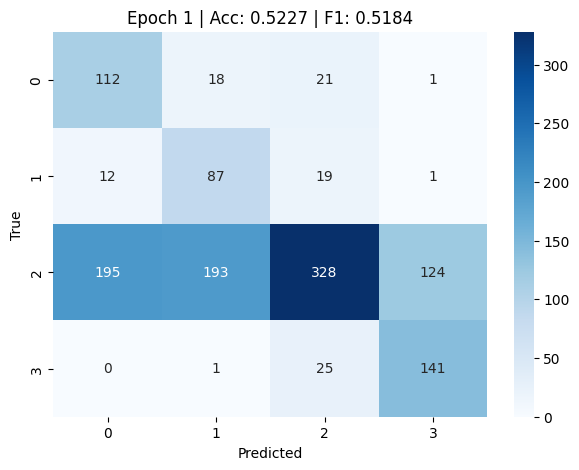

Epoch 1 | Overall Acc: 0.5227 | F1: 0.5184
Class-wise Accuracies:
  Class 0: 0.7368
  Class 1: 0.7311
  Class 2: 0.3905
  Class 3: 0.8443


Epoch 2: 100%|██████████| 169/169 [00:08<00:00, 20.91it/s, loss=1.05] 


Val Acc: 0.4937 | F1: 0.5291 | Dist: Counter({np.int64(1): 492, np.int64(2): 363, np.int64(0): 282, np.int64(3): 141})


Epoch 3: 100%|██████████| 169/169 [00:08<00:00, 20.64it/s, loss=0.981]


Val Acc: 0.5430 | F1: 0.5685 | Dist: Counter({np.int64(1): 497, np.int64(2): 414, np.int64(0): 203, np.int64(3): 164})
>>> New Best Model Saved (Acc: 0.5430)


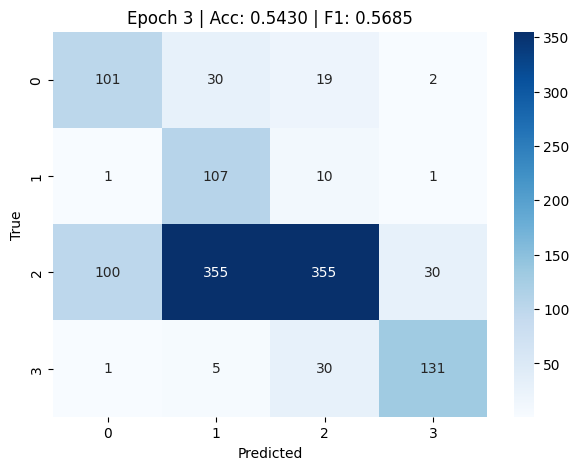

Epoch 3 | Overall Acc: 0.5430 | F1: 0.5685
Class-wise Accuracies:
  Class 0: 0.6645
  Class 1: 0.8992
  Class 2: 0.4226
  Class 3: 0.7844


Epoch 4: 100%|██████████| 169/169 [00:08<00:00, 20.61it/s, loss=0.952]


Val Acc: 0.6784 | F1: 0.6573 | Dist: Counter({np.int64(2): 545, np.int64(0): 289, np.int64(1): 245, np.int64(3): 199})
>>> New Best Model Saved (Acc: 0.6784)


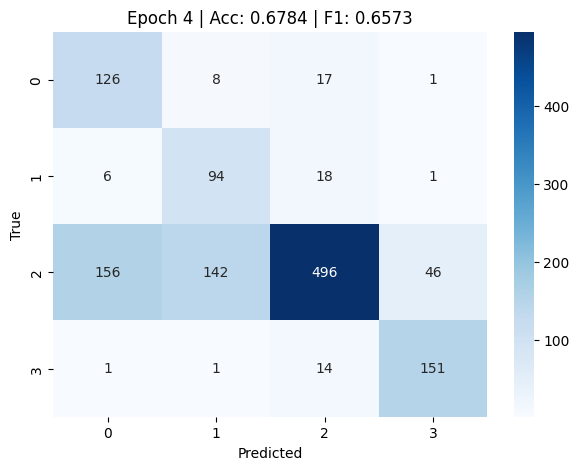

Epoch 4 | Overall Acc: 0.6784 | F1: 0.6573
Class-wise Accuracies:
  Class 0: 0.8289
  Class 1: 0.7899
  Class 2: 0.5905
  Class 3: 0.9042


Epoch 5: 100%|██████████| 169/169 [00:08<00:00, 20.72it/s, loss=0.917]


Val Acc: 0.6698 | F1: 0.6380 | Dist: Counter({np.int64(2): 543, np.int64(3): 292, np.int64(1): 243, np.int64(0): 200})


Epoch 6: 100%|██████████| 169/169 [00:08<00:00, 20.89it/s, loss=0.882]


Val Acc: 0.6205 | F1: 0.6178 | Dist: Counter({np.int64(2): 437, np.int64(0): 327, np.int64(1): 292, np.int64(3): 222})


Epoch 7: 100%|██████████| 169/169 [00:08<00:00, 20.74it/s, loss=0.857]


Val Acc: 0.7136 | F1: 0.6817 | Dist: Counter({np.int64(2): 589, np.int64(0): 263, np.int64(3): 214, np.int64(1): 212})
>>> New Best Model Saved (Acc: 0.7136)


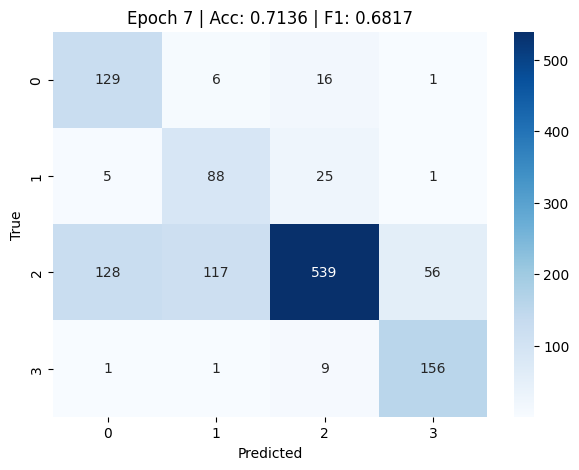

Epoch 7 | Overall Acc: 0.7136 | F1: 0.6817
Class-wise Accuracies:
  Class 0: 0.8487
  Class 1: 0.7395
  Class 2: 0.6417
  Class 3: 0.9341


Epoch 8: 100%|██████████| 169/169 [00:08<00:00, 20.84it/s, loss=0.831]


Val Acc: 0.7355 | F1: 0.6814 | Dist: Counter({np.int64(2): 692, np.int64(0): 246, np.int64(3): 202, np.int64(1): 138})
>>> New Best Model Saved (Acc: 0.7355)


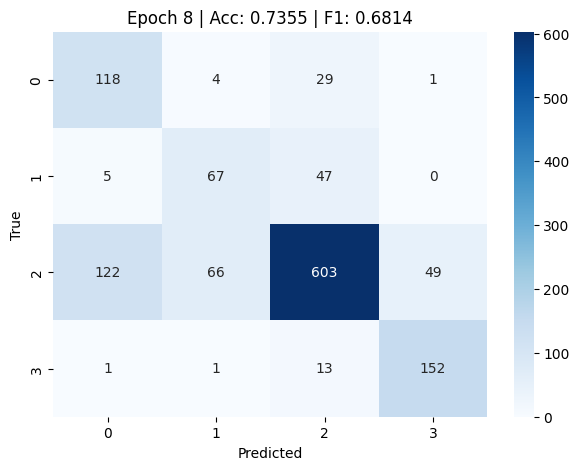

Epoch 8 | Overall Acc: 0.7355 | F1: 0.6814
Class-wise Accuracies:
  Class 0: 0.7763
  Class 1: 0.5630
  Class 2: 0.7179
  Class 3: 0.9102


Epoch 9: 100%|██████████| 169/169 [00:08<00:00, 20.77it/s, loss=0.811]


Val Acc: 0.4703 | F1: 0.5349 | Dist: Counter({np.int64(1): 606, np.int64(0): 257, np.int64(2): 256, np.int64(3): 159})


Epoch 10: 100%|██████████| 169/169 [00:08<00:00, 20.88it/s, loss=0.785]


Val Acc: 0.7199 | F1: 0.6642 | Dist: Counter({np.int64(2): 673, np.int64(3): 244, np.int64(0): 225, np.int64(1): 136})


Epoch 11: 100%|██████████| 169/169 [00:08<00:00, 20.00it/s, loss=0.767]


Val Acc: 0.5923 | F1: 0.5775 | Dist: Counter({np.int64(2): 442, np.int64(3): 382, np.int64(0): 241, np.int64(1): 213})


Epoch 12: 100%|██████████| 169/169 [00:08<00:00, 19.80it/s, loss=0.744]


Val Acc: 0.7637 | F1: 0.6651 | Dist: Counter({np.int64(2): 864, np.int64(3): 186, np.int64(1): 118, np.int64(0): 110})
>>> New Best Model Saved (Acc: 0.7637)


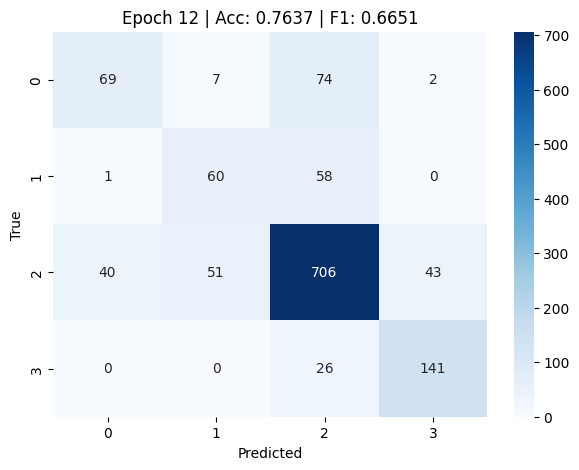

Epoch 12 | Overall Acc: 0.7637 | F1: 0.6651
Class-wise Accuracies:
  Class 0: 0.4539
  Class 1: 0.5042
  Class 2: 0.8405
  Class 3: 0.8443


Epoch 13: 100%|██████████| 169/169 [00:08<00:00, 20.51it/s, loss=0.722]


Val Acc: 0.6659 | F1: 0.6324 | Dist: Counter({np.int64(2): 582, np.int64(0): 292, np.int64(1): 204, np.int64(3): 200})


Epoch 14: 100%|██████████| 169/169 [00:08<00:00, 20.87it/s, loss=0.713]


Val Acc: 0.7121 | F1: 0.6472 | Dist: Counter({np.int64(2): 743, np.int64(1): 241, np.int64(3): 166, np.int64(0): 128})


Epoch 15: 100%|██████████| 169/169 [00:08<00:00, 20.72it/s, loss=0.696]


Val Acc: 0.7465 | F1: 0.6413 | Dist: Counter({np.int64(2): 906, np.int64(1): 149, np.int64(3): 119, np.int64(0): 104})


Epoch 16: 100%|██████████| 169/169 [00:08<00:00, 20.69it/s, loss=0.681]


Val Acc: 0.7676 | F1: 0.6671 | Dist: Counter({np.int64(2): 889, np.int64(3): 146, np.int64(0): 127, np.int64(1): 116})
>>> New Best Model Saved (Acc: 0.7676)


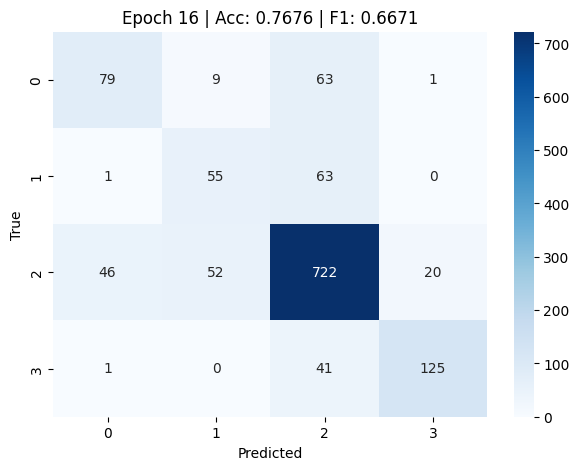

Epoch 16 | Overall Acc: 0.7676 | F1: 0.6671
Class-wise Accuracies:
  Class 0: 0.5197
  Class 1: 0.4622
  Class 2: 0.8595
  Class 3: 0.7485


Epoch 17: 100%|██████████| 169/169 [00:08<00:00, 20.83it/s, loss=0.677]


Val Acc: 0.7676 | F1: 0.6755 | Dist: Counter({np.int64(2): 854, np.int64(3): 188, np.int64(0): 139, np.int64(1): 97})


Epoch 18: 100%|██████████| 169/169 [00:08<00:00, 20.83it/s, loss=0.664]


Val Acc: 0.7653 | F1: 0.6623 | Dist: Counter({np.int64(2): 905, np.int64(0): 142, np.int64(3): 140, np.int64(1): 91})


...

Val Acc: 0.7371 | F1: 0.6710 | Dist: Counter({np.int64(2): 759, np.int64(1): 197, np.int64(0): 163, np.int64(3): 159})


Epoch 27: 100%|██████████| 169/169 [00:08<00:00, 20.61it/s, loss=0.604]


Val Acc: 0.7465 | F1: 0.6217 | Dist: Counter({np.int64(2): 967, np.int64(0): 113, np.int64(1): 104, np.int64(3): 94})


Epoch 28: 100%|██████████| 169/169 [00:08<00:00, 20.60it/s, loss=0.599]


Val Acc: 0.7770 | F1: 0.6755 | Dist: Counter({np.int64(2): 881, np.int64(3): 183, np.int64(0): 139, np.int64(1): 75})
>>> New Best Model Saved (Acc: 0.7770)


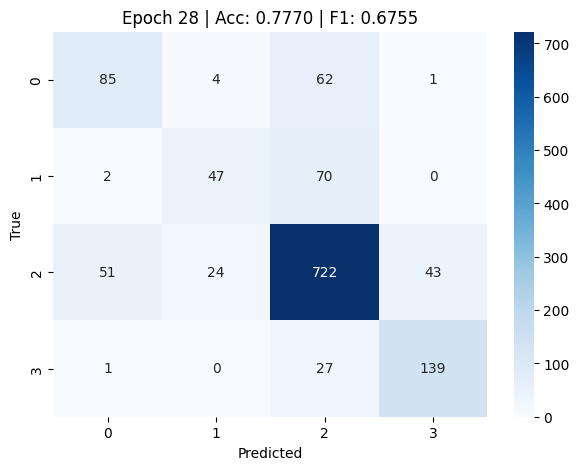

Epoch 28 | Overall Acc: 0.7770 | F1: 0.6755
Class-wise Accuracies:
  Class 0: 0.5592
  Class 1: 0.3950
  Class 2: 0.8595
  Class 3: 0.8323


Epoch 29: 100%|██████████| 169/169 [00:08<00:00, 19.78it/s, loss=0.597]


Val Acc: 0.7653 | F1: 0.6892 | Dist: Counter({np.int64(2): 807, np.int64(3): 175, np.int64(0): 165, np.int64(1): 131})


Epoch 30: 100%|██████████| 169/169 [00:08<00:00, 20.84it/s, loss=0.591]


Val Acc: 0.7426 | F1: 0.6792 | Dist: Counter({np.int64(2): 733, np.int64(3): 206, np.int64(0): 170, np.int64(1): 169})


...

Val Acc: 0.7613 | F1: 0.6721 | Dist: Counter({np.int64(2): 857, np.int64(3): 170, np.int64(1): 127, np.int64(0): 124})


Epoch 49: 100%|██████████| 169/169 [00:08<00:00, 19.99it/s, loss=0.569]


Val Acc: 0.7613 | F1: 0.6725 | Dist: Counter({np.int64(2): 859, np.int64(3): 165, np.int64(1): 130, np.int64(0): 124})


Epoch 50: 100%|██████████| 169/169 [00:08<00:00, 19.88it/s, loss=0.568]


Val Acc: 0.7590 | F1: 0.6664 | Dist: Counter({np.int64(2): 866, np.int64(3): 165, np.int64(1): 126, np.int64(0): 121})
Final Best Val Accuracy: 0.7770


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import os
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# --- 环境设置 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_dir = os.path.join(os.getcwd(), 'sleep-edf', 'data')
model_save_path = os.path.join(data_dir, 'model', 'model011904.pth')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# --- 超参数 ---
batch_size = 64
lr = 3e-4
num_epochs = 50
num_classes = 4

# --- 1. 核心逻辑：按患者构建时序数据（5-Epoch 窗口）---
def load_context_data(root_path, window_size=5):
    """
    遍历 patient_data 文件夹，构建 5-Epoch 窗口：(t-2, t-1, t, t+1, t+2)
    """
    patient_dir = os.path.join(root_path, 'patient_data')
    X_all, y_all = [], []
    
    if not os.path.exists(patient_dir):
        raise FileNotFoundError(f"找不到路径: {patient_dir}")

    x_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('_X.npy')])
    
    print(f"Loading patients from {patient_dir}...")
    half_window = window_size // 2
    for f in tqdm(x_files):
        patient_id = f.replace('_X.npy', '')
        x_sub = np.load(os.path.join(patient_dir, f))
        y_sub = np.load(os.path.join(patient_dir, f"{patient_id}_y.npy"))
        
        # 标签清理与映射
        valid = (y_sub != -1)
        x_sub, y_sub = x_sub[valid], y_sub[valid]
        
        y_mapped = np.zeros_like(y_sub)
        y_mapped[y_sub == 0] = 0  # W
        y_mapped[y_sub == 4] = 1  # REM
        y_mapped[(y_sub == 1) | (y_sub == 2)] = 2  # Light (N1+N2)
        y_mapped[y_sub == 3] = 3  # Deep (N3)
        
        # 构建 5-Epoch 窗口
        for i in range(half_window, len(x_sub) - half_window):
            window = x_sub[i - half_window: i + half_window + 1]  # (5, 3000)
            X_all.append(window)
            y_all.append(y_mapped[i])
            
    return np.array(X_all), np.array(y_all)

# --- 2. 数据集类（增强增广：噪声 + 随机遮罩，移除时间拉伸）---
class SleepContextDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32).float()  # 确保 float
        self.y = torch.tensor(y, dtype=torch.long)
        
        # 全局标准化
        mean, std = self.X.mean(), self.X.std()
        self.X = (self.X - mean) / (std + 1e-6)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        
        if self.augment and x.is_floating_point():
            # 原增强：微小噪声
            if torch.rand(1) < 0.3:
                x = x + torch.randn_like(x) * 0.005
            # 保留：随机遮罩（10% 信号丢失）
            if torch.rand(1) < 0.25:
                mask = torch.rand_like(x) > 0.1  # 适用于 float
                x = x * mask
        
        return x, y

# --- 3. 模型（5通道输入）---
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ELU(),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se = SEBlock(out_ch) # 新增注意力
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        self.elu = nn.ELU()

    def forward(self, x):
        out = self.conv(x)
        out = self.se(out) # 赋予特征通道权重
        return self.elu(out + self.shortcut(x))


class SleepStageNetV8(nn.Module):
    def __init__(self, num_classes, window_size=5):
        super().__init__()
        self.window_size = window_size
        self.n_fft = 512
        self.hop_length = 64
        
        # --- 分支 A: 频谱特征提取 (2D CNN) ---
        self.spec_stem = nn.Sequential(
            nn.Conv2d(1, 32, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU()
        )
        self.spec_stage = nn.Sequential(
            ResBlock(32, 64, stride=2),
            ResBlock(64, 128, stride=2),
            ResBlock(128, 128, stride=2), # 缩减输出通道为128
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        # --- 分支 B: 原始波形特征提取 (1D CNN) ---
        # 模仿 TinySleepNet/DeepSleepNet 的小核+大核思想简化版
        self.raw_branch = nn.Sequential(
            # 第一层使用较大的卷积核捕捉低频节律 (如 Delta 波)
            nn.Conv1d(1, 64, kernel_size=64, stride=8, padding=32, bias=False),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.MaxPool1d(kernel_size=8, stride=8),
            # 第二层捕捉局部细节
            nn.Conv1d(64, 128, kernel_size=16, stride=1, padding=8, bias=False),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.AdaptiveAvgPool1d(1) # 输出维度 (B*T, 128, 1)
        )
        
        # --- 融合与时序层 ---
        # 两个分支各出 128 维，合起来是 256
        self.rnn = nn.GRU(128 + 128, 128, num_layers=2, bidirectional=True, batch_first=True, dropout=0.3)
        
        # 分类器
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: [Batch, 5, 1, 3001]
        b, t, c, s = x.shape
        x_flat = x.view(b * t, c, s) # [B*T, 1, 3001]
        
        # --- 1. 频谱分支 (2D) ---
        # 在 forward 内部计算频谱
        win = torch.hann_window(self.n_fft).to(x.device)
        stft = torch.stft(x_flat.squeeze(1), n_fft=self.n_fft, hop_length=self.hop_length, 
                          window=win, return_complex=True, center=True)
        mag = (torch.abs(stft) + 1e-8).log().unsqueeze(1) # [B*T, 1, F, T]
        mag = mag[:, :, :128, :] # 取低频部分
        
        spec_fea = self.spec_stem(mag)
        spec_fea = self.spec_stage(spec_fea).flatten(1) # [B*T, 128]
        
        # --- 2. 原始波形分支 (1D) ---
        raw_fea = self.raw_branch(x_flat).flatten(1) # [B*T, 128]
        
        # --- 3. 特征融合 ---
        combined_fea = torch.cat([spec_fea, raw_fea], dim=1) # [B*T, 256]
        
        # --- 4. 还原序列维度过 RNN ---
        combined_fea = combined_fea.view(b, t, -1) # [B, 5, 256]
        rnn_out, _ = self.rnn(combined_fea)  # [B, 5, 256]
        
        # --- 5. 取中间 Epoch 输出 ---
        mid_idx = t // 2
        return self.classifier(rnn_out[:, mid_idx, :])



# --- 4. 评估 ---
def evaluate(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x.to(device))
            all_p.extend(outputs.argmax(1).cpu().numpy())
            all_l.extend(y.numpy())
    return accuracy_score(all_l, all_p), f1_score(all_l, all_p, average='macro'), confusion_matrix(all_l, all_p), Counter(all_p)

def print_confusion_matrix(cm, acc, f1, epoch):
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Epoch {epoch} | Acc: {acc:.4f} | F1: {f1:.4f}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
    # 计算每个分类的准确率
    class_accuracies = cm.diagonal() / cm.sum(axis=1)
    print(f"Epoch {epoch} | Overall Acc: {acc:.4f} | F1: {f1:.4f}")
    print("Class-wise Accuracies:")
    for i, class_acc in enumerate(class_accuracies):
        print(f"  Class {i}: {class_acc:.4f}")

# --- 5. 主训练程序 ---
if __name__ == "__main__":
    window_size = 5
    train_X, train_y = load_context_data(os.path.join(data_dir, 'train', 'cache'), window_size=window_size)
    val_X, val_y = load_context_data(os.path.join(data_dir, 'val', 'cache'), window_size=window_size)
    
    train_loader = DataLoader(SleepContextDataset(train_X, train_y, augment=True), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SleepContextDataset(val_X, val_y), batch_size=batch_size)

    model = SleepStageNetV8(num_classes=num_classes, window_size=window_size).to(device)
    
    # cls_weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
    # cls_weights = torch.tensor(cls_weights, dtype=torch.float32).to(device)
    cls_weights = torch.tensor([3.0, 4.0, 0.5, 1.0]).to(device)
    criterion = nn.CrossEntropyLoss(weight=cls_weights, label_smoothing=0.1)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    best_acc = 0
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=total_loss / len(pbar))
        
        acc, f1, cm, preds_counter = evaluate(model, val_loader)
        print(f"Val Acc: {acc:.4f} | F1: {f1:.4f} | Dist: {preds_counter}")
        
        scheduler.step()
        
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), model_save_path)
            print(f">>> New Best Model Saved (Acc: {best_acc:.4f})")
            print_confusion_matrix(cm, acc, f1, epoch+1)

    print(f"Final Best Val Accuracy: {best_acc:.4f}")


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\train\cache\patient_data...


100%|██████████| 122/122 [00:00<00:00, 400.30it/s]


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\val\cache\patient_data...


Epoch 1: 100%|██████████| 75/75 [00:22<00:00,  3.30it/s, loss=1.29] 


Val Acc: 0.4512 | F1: 0.4367 | Dist: Counter({np.int64(3): 393, np.int64(0): 337, np.int64(2): 273, np.int64(1): 125})
>>> New Best Model Saved (Acc: 0.4512)


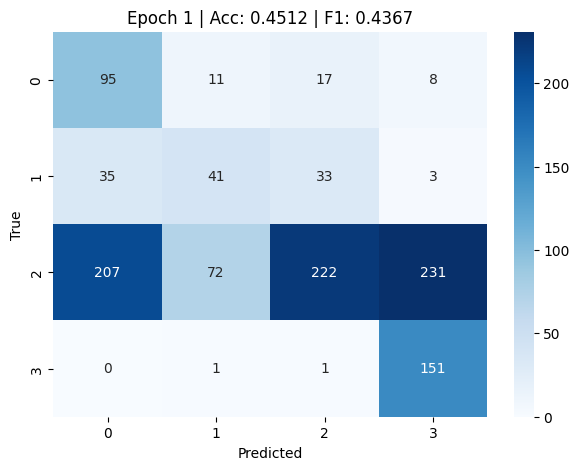

Epoch 1 | Overall Acc: 0.4512 | F1: 0.4367
Class-wise Accuracies:
  Class 0: 0.7252
  Class 1: 0.3661
  Class 2: 0.3033
  Class 3: 0.9869


Epoch 2: 100%|██████████| 75/75 [00:21<00:00,  3.52it/s, loss=1.13] 


Val Acc: 0.4840 | F1: 0.5137 | Dist: Counter({np.int64(1): 467, np.int64(2): 311, np.int64(3): 176, np.int64(0): 174})
>>> New Best Model Saved (Acc: 0.4840)


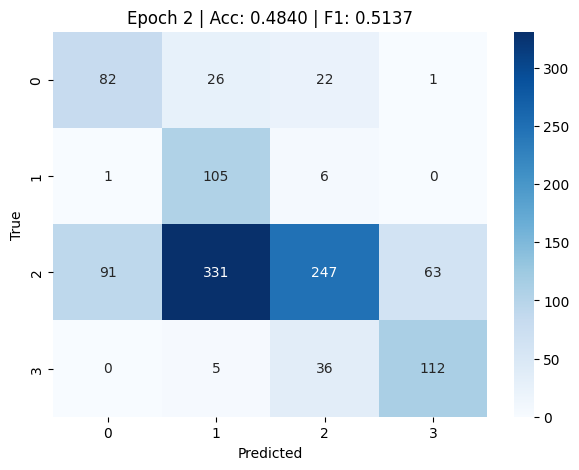

Epoch 2 | Overall Acc: 0.4840 | F1: 0.5137
Class-wise Accuracies:
  Class 0: 0.6260
  Class 1: 0.9375
  Class 2: 0.3374
  Class 3: 0.7320


Epoch 3: 100%|██████████| 75/75 [00:22<00:00,  3.30it/s, loss=1.02] 


Val Acc: 0.5399 | F1: 0.5566 | Dist: Counter({np.int64(0): 344, np.int64(2): 319, np.int64(1): 282, np.int64(3): 183})
>>> New Best Model Saved (Acc: 0.5399)


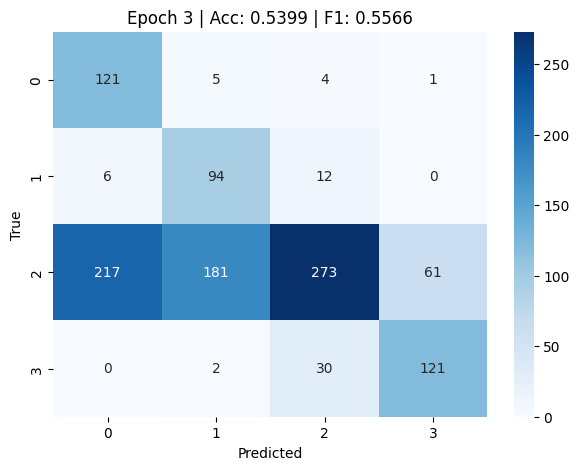

Epoch 3 | Overall Acc: 0.5399 | F1: 0.5566
Class-wise Accuracies:
  Class 0: 0.9237
  Class 1: 0.8393
  Class 2: 0.3730
  Class 3: 0.7908


Epoch 4: 100%|██████████| 75/75 [00:21<00:00,  3.54it/s, loss=0.967]


Val Acc: 0.2651 | F1: 0.3240 | Dist: Counter({np.int64(1): 854, np.int64(0): 128, np.int64(2): 111, np.int64(3): 35})


Epoch 5: 100%|██████████| 75/75 [00:21<00:00,  3.56it/s, loss=0.928]


Val Acc: 0.6924 | F1: 0.6702 | Dist: Counter({np.int64(2): 497, np.int64(0): 271, np.int64(3): 192, np.int64(1): 168})
>>> New Best Model Saved (Acc: 0.6924)


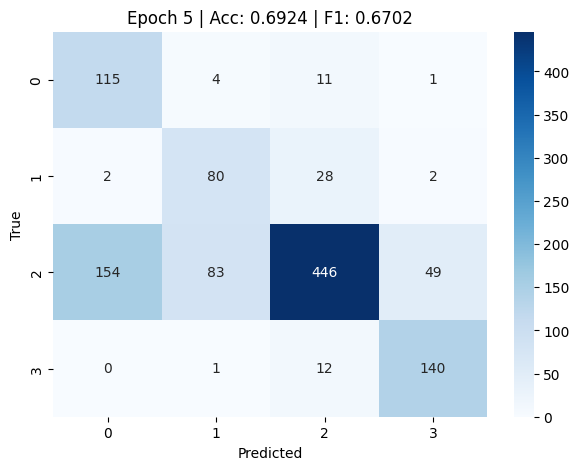

Epoch 5 | Overall Acc: 0.6924 | F1: 0.6702
Class-wise Accuracies:
  Class 0: 0.8779
  Class 1: 0.7143
  Class 2: 0.6093
  Class 3: 0.9150


Epoch 6: 100%|██████████| 75/75 [00:20<00:00,  3.57it/s, loss=0.896]


Val Acc: 0.5576 | F1: 0.5716 | Dist: Counter({np.int64(1): 390, np.int64(2): 322, np.int64(3): 229, np.int64(0): 187})


Epoch 7: 100%|██████████| 75/75 [00:21<00:00,  3.57it/s, loss=0.864]


Val Acc: 0.5842 | F1: 0.6020 | Dist: Counter({np.int64(1): 412, np.int64(2): 371, np.int64(3): 189, np.int64(0): 156})


Epoch 8: 100%|██████████| 75/75 [00:21<00:00,  3.57it/s, loss=0.832]


Val Acc: 0.7163 | F1: 0.6706 | Dist: Counter({np.int64(2): 614, np.int64(0): 200, np.int64(1): 176, np.int64(3): 138})
>>> New Best Model Saved (Acc: 0.7163)


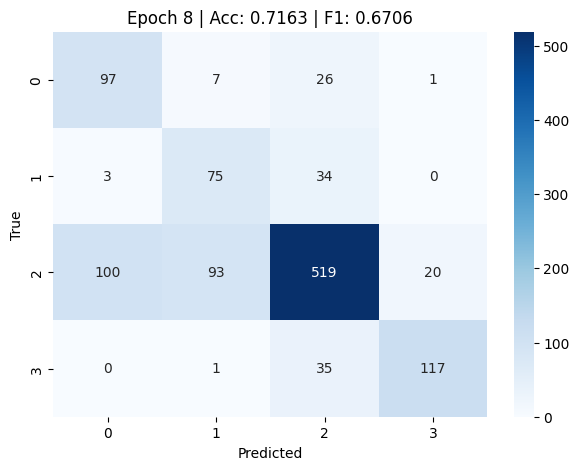

Epoch 8 | Overall Acc: 0.7163 | F1: 0.6706
Class-wise Accuracies:
  Class 0: 0.7405
  Class 1: 0.6696
  Class 2: 0.7090
  Class 3: 0.7647


Epoch 9: 100%|██████████| 75/75 [00:20<00:00,  3.58it/s, loss=0.801]


Val Acc: 0.7261 | F1: 0.6847 | Dist: Counter({np.int64(2): 584, np.int64(3): 182, np.int64(1): 181, np.int64(0): 181})
>>> New Best Model Saved (Acc: 0.7261)


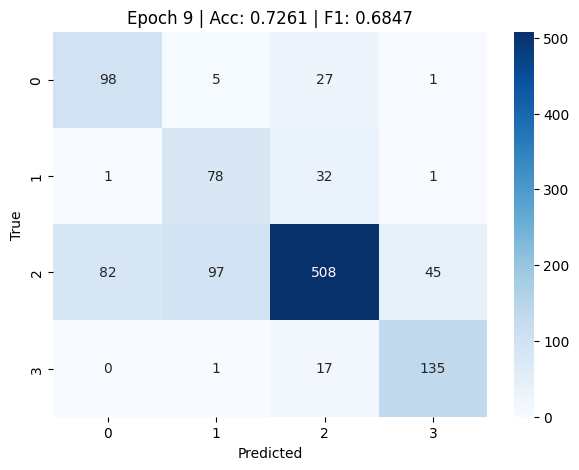

Epoch 9 | Overall Acc: 0.7261 | F1: 0.6847
Class-wise Accuracies:
  Class 0: 0.7481
  Class 1: 0.6964
  Class 2: 0.6940
  Class 3: 0.8824


Epoch 10: 100%|██████████| 75/75 [00:21<00:00,  3.57it/s, loss=0.77]  


Val Acc: 0.7039 | F1: 0.6656 | Dist: Counter({np.int64(2): 558, np.int64(1): 198, np.int64(0): 194, np.int64(3): 178})


Epoch 11: 100%|██████████| 75/75 [00:21<00:00,  3.54it/s, loss=0.751] 


Val Acc: 0.6676 | F1: 0.6425 | Dist: Counter({np.int64(2): 485, np.int64(0): 233, np.int64(1): 212, np.int64(3): 198})


Epoch 12: 100%|██████████| 75/75 [00:21<00:00,  3.55it/s, loss=0.73]  


Val Acc: 0.6915 | F1: 0.6623 | Dist: Counter({np.int64(2): 507, np.int64(0): 267, np.int64(3): 200, np.int64(1): 154})


Epoch 13: 100%|██████████| 75/75 [00:21<00:00,  3.52it/s, loss=0.707] 


Val Acc: 0.7535 | F1: 0.7009 | Dist: Counter({np.int64(2): 639, np.int64(0): 190, np.int64(3): 177, np.int64(1): 122})
>>> New Best Model Saved (Acc: 0.7535)


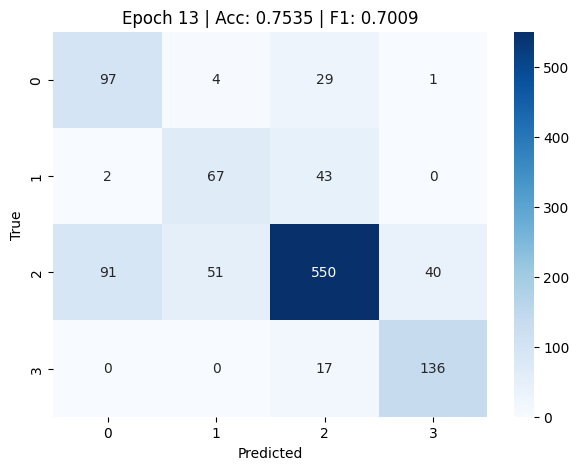

Epoch 13 | Overall Acc: 0.7535 | F1: 0.7009
Class-wise Accuracies:
  Class 0: 0.7405
  Class 1: 0.5982
  Class 2: 0.7514
  Class 3: 0.8889


Epoch 14: 100%|██████████| 75/75 [00:21<00:00,  3.55it/s, loss=0.69]  


Val Acc: 0.7447 | F1: 0.6933 | Dist: Counter({np.int64(2): 613, np.int64(3): 200, np.int64(0): 196, np.int64(1): 119})


Epoch 15: 100%|██████████| 75/75 [00:21<00:00,  3.55it/s, loss=0.674] 


Val Acc: 0.7465 | F1: 0.7028 | Dist: Counter({np.int64(2): 615, np.int64(0): 185, np.int64(3): 168, np.int64(1): 160})


...

Val Acc: 0.7181 | F1: 0.6746 | Dist: Counter({np.int64(2): 570, np.int64(3): 213, np.int64(1): 187, np.int64(0): 158})


Epoch 17: 100%|██████████| 75/75 [00:21<00:00,  3.54it/s, loss=0.655] 


Val Acc: 0.7145 | F1: 0.6734 | Dist: Counter({np.int64(2): 580, np.int64(1): 206, np.int64(3): 179, np.int64(0): 163})


Epoch 18: 100%|██████████| 75/75 [00:21<00:00,  3.54it/s, loss=0.651] 


Val Acc: 0.7695 | F1: 0.7005 | Dist: Counter({np.int64(2): 709, np.int64(3): 158, np.int64(1): 148, np.int64(0): 113})
>>> New Best Model Saved (Acc: 0.7695)


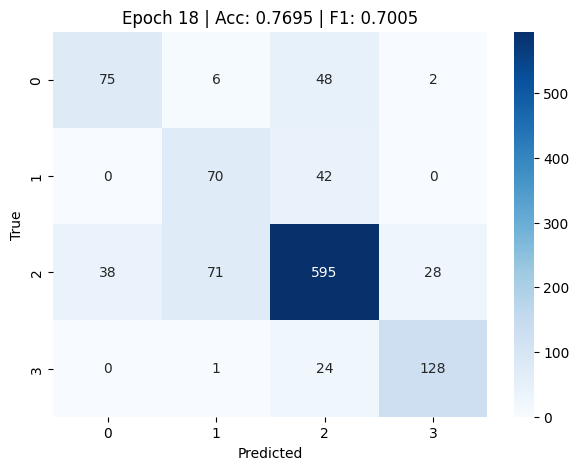

Epoch 18 | Overall Acc: 0.7695 | F1: 0.7005
Class-wise Accuracies:
  Class 0: 0.5725
  Class 1: 0.6250
  Class 2: 0.8128
  Class 3: 0.8366


Epoch 19: 100%|██████████| 75/75 [00:21<00:00,  3.52it/s, loss=0.633] 


Val Acc: 0.7473 | F1: 0.6816 | Dist: Counter({np.int64(2): 677, np.int64(3): 169, np.int64(1): 164, np.int64(0): 118})


Epoch 20: 100%|██████████| 75/75 [00:21<00:00,  3.51it/s, loss=0.63]  


Val Acc: 0.7553 | F1: 0.6852 | Dist: Counter({np.int64(2): 711, np.int64(3): 154, np.int64(1): 136, np.int64(0): 127})


...

Val Acc: 0.7615 | F1: 0.6957 | Dist: Counter({np.int64(2): 696, np.int64(3): 165, np.int64(1): 139, np.int64(0): 128})


Epoch 26: 100%|██████████| 75/75 [00:22<00:00,  3.40it/s, loss=0.601] 


Val Acc: 0.7518 | F1: 0.6870 | Dist: Counter({np.int64(2): 668, np.int64(3): 199, np.int64(0): 149, np.int64(1): 112})


Epoch 27: 100%|██████████| 75/75 [00:21<00:00,  3.52it/s, loss=0.589] 


Val Acc: 0.7722 | F1: 0.7040 | Dist: Counter({np.int64(2): 703, np.int64(3): 165, np.int64(1): 131, np.int64(0): 129})
>>> New Best Model Saved (Acc: 0.7722)


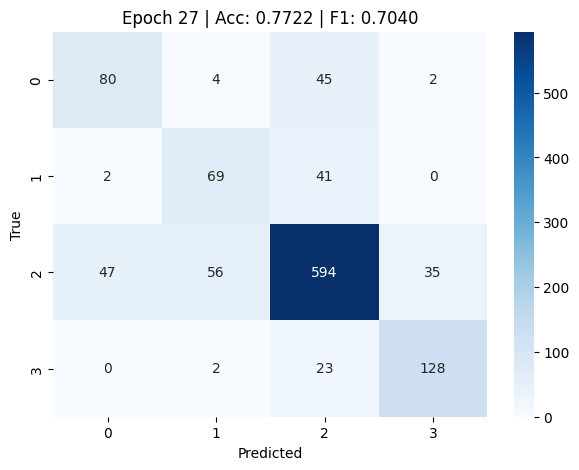

Epoch 27 | Overall Acc: 0.7722 | F1: 0.7040
Class-wise Accuracies:
  Class 0: 0.6107
  Class 1: 0.6161
  Class 2: 0.8115
  Class 3: 0.8366


Epoch 28: 100%|██████████| 75/75 [00:22<00:00,  3.37it/s, loss=0.59]  


Val Acc: 0.7394 | F1: 0.6832 | Dist: Counter({np.int64(2): 651, np.int64(0): 175, np.int64(3): 153, np.int64(1): 149})


Epoch 29: 100%|██████████| 75/75 [00:21<00:00,  3.45it/s, loss=0.589] 


Val Acc: 0.7270 | F1: 0.6569 | Dist: Counter({np.int64(2): 713, np.int64(1): 190, np.int64(0): 124, np.int64(3): 101})


Epoch 30: 100%|██████████| 75/75 [00:21<00:00,  3.50it/s, loss=0.583] 


Val Acc: 0.7748 | F1: 0.6987 | Dist: Counter({np.int64(2): 733, np.int64(3): 166, np.int64(0): 120, np.int64(1): 109})
>>> New Best Model Saved (Acc: 0.7748)


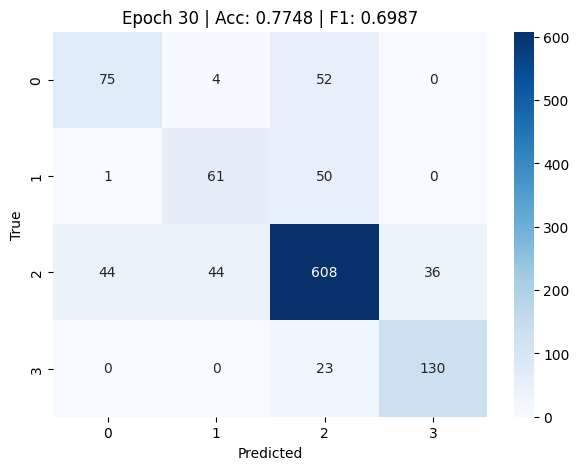

Epoch 30 | Overall Acc: 0.7748 | F1: 0.6987
Class-wise Accuracies:
  Class 0: 0.5725
  Class 1: 0.5446
  Class 2: 0.8306
  Class 3: 0.8497


Epoch 31: 100%|██████████| 75/75 [00:21<00:00,  3.43it/s, loss=0.584] 


Val Acc: 0.7651 | F1: 0.7004 | Dist: Counter({np.int64(2): 690, np.int64(3): 166, np.int64(1): 153, np.int64(0): 119})


Epoch 32: 100%|██████████| 75/75 [00:21<00:00,  3.50it/s, loss=0.576] 


Val Acc: 0.7784 | F1: 0.7103 | Dist: Counter({np.int64(2): 706, np.int64(3): 174, np.int64(1): 125, np.int64(0): 123})
>>> New Best Model Saved (Acc: 0.7784)


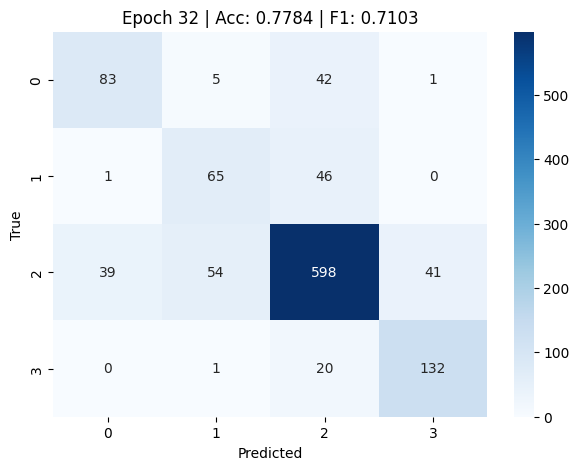

Epoch 32 | Overall Acc: 0.7784 | F1: 0.7103
Class-wise Accuracies:
  Class 0: 0.6336
  Class 1: 0.5804
  Class 2: 0.8169
  Class 3: 0.8627


Epoch 33: 100%|██████████| 75/75 [00:21<00:00,  3.53it/s, loss=0.579] 


Val Acc: 0.7473 | F1: 0.6880 | Dist: Counter({np.int64(2): 657, np.int64(3): 188, np.int64(1): 158, np.int64(0): 125})


Epoch 34: 100%|██████████| 75/75 [00:21<00:00,  3.51it/s, loss=0.575] 


Val Acc: 0.7722 | F1: 0.6871 | Dist: Counter({np.int64(2): 740, np.int64(3): 197, np.int64(0): 98, np.int64(1): 93})


Epoch 35: 100%|██████████| 75/75 [00:21<00:00,  3.48it/s, loss=0.566] 


Val Acc: 0.7615 | F1: 0.6857 | Dist: Counter({np.int64(2): 734, np.int64(1): 154, np.int64(3): 146, np.int64(0): 94})


Epoch 36: 100%|██████████| 75/75 [00:21<00:00,  3.49it/s, loss=0.57]  


Val Acc: 0.7810 | F1: 0.7123 | Dist: Counter({np.int64(2): 713, np.int64(3): 180, np.int64(0): 122, np.int64(1): 113})
>>> New Best Model Saved (Acc: 0.7810)


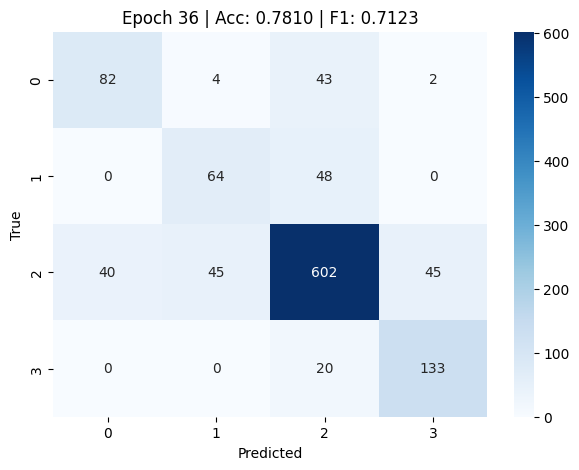

Epoch 36 | Overall Acc: 0.7810 | F1: 0.7123
Class-wise Accuracies:
  Class 0: 0.6260
  Class 1: 0.5714
  Class 2: 0.8224
  Class 3: 0.8693


Epoch 37: 100%|██████████| 75/75 [00:21<00:00,  3.42it/s, loss=0.57]  


Val Acc: 0.7801 | F1: 0.7016 | Dist: Counter({np.int64(2): 742, np.int64(3): 161, np.int64(0): 131, np.int64(1): 94})


Epoch 38: 100%|██████████| 75/75 [00:21<00:00,  3.50it/s, loss=0.568] 


Val Acc: 0.7686 | F1: 0.6950 | Dist: Counter({np.int64(2): 713, np.int64(3): 176, np.int64(0): 127, np.int64(1): 112})


Epoch 39: 100%|██████████| 75/75 [00:21<00:00,  3.42it/s, loss=0.57]  


Val Acc: 0.7766 | F1: 0.7132 | Dist: Counter({np.int64(2): 688, np.int64(3): 176, np.int64(0): 140, np.int64(1): 124})


Epoch 40: 100%|██████████| 75/75 [00:21<00:00,  3.42it/s, loss=0.566] 


Val Acc: 0.7846 | F1: 0.7148 | Dist: Counter({np.int64(2): 713, np.int64(3): 174, np.int64(0): 130, np.int64(1): 111})
>>> New Best Model Saved (Acc: 0.7846)


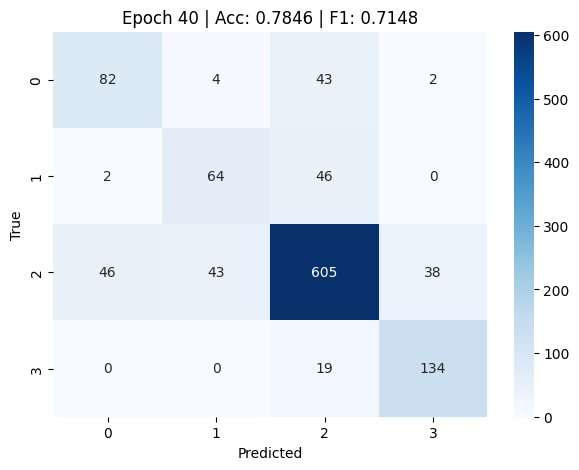

Epoch 40 | Overall Acc: 0.7846 | F1: 0.7148
Class-wise Accuracies:
  Class 0: 0.6260
  Class 1: 0.5714
  Class 2: 0.8265
  Class 3: 0.8758


Epoch 41: 100%|██████████| 75/75 [00:21<00:00,  3.46it/s, loss=0.564] 


Val Acc: 0.7810 | F1: 0.7113 | Dist: Counter({np.int64(2): 730, np.int64(3): 147, np.int64(0): 131, np.int64(1): 120})


Epoch 42: 100%|██████████| 75/75 [00:21<00:00,  3.56it/s, loss=0.561] 


Val Acc: 0.7863 | F1: 0.7203 | Dist: Counter({np.int64(2): 702, np.int64(3): 177, np.int64(0): 128, np.int64(1): 121})
>>> New Best Model Saved (Acc: 0.7863)


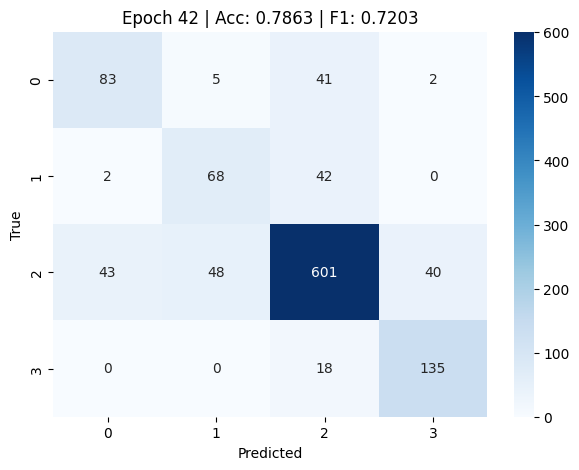

Epoch 42 | Overall Acc: 0.7863 | F1: 0.7203
Class-wise Accuracies:
  Class 0: 0.6336
  Class 1: 0.6071
  Class 2: 0.8210
  Class 3: 0.8824


Epoch 43: 100%|██████████| 75/75 [00:21<00:00,  3.44it/s, loss=0.564] 


Val Acc: 0.7819 | F1: 0.7114 | Dist: Counter({np.int64(2): 725, np.int64(3): 161, np.int64(0): 122, np.int64(1): 120})


Epoch 44: 100%|██████████| 75/75 [00:21<00:00,  3.50it/s, loss=0.562] 


Val Acc: 0.7855 | F1: 0.7144 | Dist: Counter({np.int64(2): 718, np.int64(3): 174, np.int64(0): 121, np.int64(1): 115})


...

Val Acc: 0.7846 | F1: 0.7169 | Dist: Counter({np.int64(2): 713, np.int64(3): 170, np.int64(0): 126, np.int64(1): 119})


Epoch 47: 100%|██████████| 75/75 [00:21<00:00,  3.50it/s, loss=0.558] 


Val Acc: 0.7819 | F1: 0.7108 | Dist: Counter({np.int64(2): 726, np.int64(3): 164, np.int64(0): 122, np.int64(1): 116})


Epoch 48: 100%|██████████| 75/75 [00:21<00:00,  3.44it/s, loss=0.56]  


Val Acc: 0.7890 | F1: 0.7237 | Dist: Counter({np.int64(2): 712, np.int64(3): 166, np.int64(0): 132, np.int64(1): 118})
>>> New Best Model Saved (Acc: 0.7890)


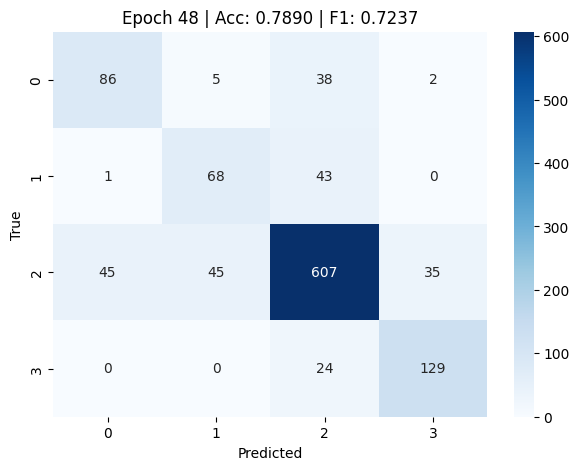

Epoch 48 | Overall Acc: 0.7890 | F1: 0.7237
Class-wise Accuracies:
  Class 0: 0.6565
  Class 1: 0.6071
  Class 2: 0.8292
  Class 3: 0.8431


Epoch 49: 100%|██████████| 75/75 [00:21<00:00,  3.54it/s, loss=0.559] 


Val Acc: 0.7881 | F1: 0.7224 | Dist: Counter({np.int64(2): 717, np.int64(3): 159, np.int64(0): 134, np.int64(1): 118})


Epoch 50: 100%|██████████| 75/75 [00:21<00:00,  3.41it/s, loss=0.558] 


Val Acc: 0.7855 | F1: 0.7189 | Dist: Counter({np.int64(2): 716, np.int64(3): 162, np.int64(0): 128, np.int64(1): 122})
Final Best Val Accuracy: 0.7890


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import os
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# --- 环境设置 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_dir = os.path.join(os.getcwd(), 'sleep-edf', 'data')
model_save_path = os.path.join(data_dir, 'model', 'model011905.pth')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# --- 超参数 ---
batch_size = 128
window_size = 15
lr = 3e-4
num_epochs = 50
num_classes = 4

# --- 1. 核心逻辑：按患者构建时序数据（5-Epoch 窗口）---
def load_context_data(root_path, window_size=5):
    """
    遍历 patient_data 文件夹，构建 5-Epoch 窗口：(t-2, t-1, t, t+1, t+2)
    """
    patient_dir = os.path.join(root_path, 'patient_data')
    X_all, y_all = [], []
    
    if not os.path.exists(patient_dir):
        raise FileNotFoundError(f"找不到路径: {patient_dir}")

    x_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('_X.npy')])
    
    print(f"Loading patients from {patient_dir}...")
    half_window = window_size // 2
    for f in tqdm(x_files):
        patient_id = f.replace('_X.npy', '')
        x_sub = np.load(os.path.join(patient_dir, f))
        y_sub = np.load(os.path.join(patient_dir, f"{patient_id}_y.npy"))
        
        # 标签清理与映射
        valid = (y_sub != -1)
        x_sub, y_sub = x_sub[valid], y_sub[valid]
        
        y_mapped = np.zeros_like(y_sub)
        y_mapped[y_sub == 0] = 0  # W
        y_mapped[y_sub == 4] = 1  # REM
        y_mapped[(y_sub == 1) | (y_sub == 2)] = 2  # Light (N1+N2)
        y_mapped[y_sub == 3] = 3  # Deep (N3)
        
        # 构建 5-Epoch 窗口
        for i in range(half_window, len(x_sub) - half_window):
            window = x_sub[i - half_window: i + half_window + 1]  # (5, 3000)
            X_all.append(window)
            y_all.append(y_mapped[i])
            
    return np.array(X_all), np.array(y_all)

# --- 2. 数据集类（增强增广：噪声 + 随机遮罩，移除时间拉伸）---
class SleepContextDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32).float()  # 确保 float
        self.y = torch.tensor(y, dtype=torch.long)
        
        # 全局标准化
        mean, std = self.X.mean(), self.X.std()
        self.X = (self.X - mean) / (std + 1e-6)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        
        if self.augment and x.is_floating_point():
            # 原增强：微小噪声
            if torch.rand(1) < 0.3:
                x = x + torch.randn_like(x) * 0.005
            # 保留：随机遮罩（10% 信号丢失）
            if torch.rand(1) < 0.25:
                mask = torch.rand_like(x) > 0.1  # 适用于 float
                x = x * mask
        
        return x, y

# --- 3. 模型（5通道输入）---
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ELU(),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se = SEBlock(out_ch) # 新增注意力
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        self.elu = nn.ELU()

    def forward(self, x):
        out = self.conv(x)
        out = self.se(out) # 赋予特征通道权重
        return self.elu(out + self.shortcut(x))


class SleepStageNetV8(nn.Module):
    def __init__(self, num_classes, window_size=5):
        super().__init__()
        self.window_size = window_size
        self.n_fft = 512
        self.hop_length = 64
        
        # --- 分支 A: 频谱特征提取 (2D CNN) ---
        self.spec_stem = nn.Sequential(
            nn.Conv2d(1, 32, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU()
        )
        self.spec_stage = nn.Sequential(
            ResBlock(32, 64, stride=2),
            ResBlock(64, 128, stride=2),
            ResBlock(128, 128, stride=2), # 缩减输出通道为128
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        # --- 分支 B: 原始波形特征提取 (1D CNN) ---
        # 模仿 TinySleepNet/DeepSleepNet 的小核+大核思想简化版
        self.raw_branch = nn.Sequential(
            # 第一层使用较大的卷积核捕捉低频节律 (如 Delta 波)
            nn.Conv1d(1, 64, kernel_size=64, stride=8, padding=32, bias=False),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.MaxPool1d(kernel_size=8, stride=8),
            # 第二层捕捉局部细节
            nn.Conv1d(64, 128, kernel_size=16, stride=1, padding=8, bias=False),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.AdaptiveAvgPool1d(1) # 输出维度 (B*T, 128, 1)
        )
        
        # --- 融合与时序层 ---
        # 两个分支各出 128 维，合起来是 256
        self.rnn = nn.GRU(128 + 128, 128, num_layers=2, bidirectional=True, batch_first=True, dropout=0.3)
        
        # 分类器
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: [Batch, 5, 1, 3001]
        b, t, c, s = x.shape
        x_flat = x.view(b * t, c, s) # [B*T, 1, 3001]
        
        # --- 1. 频谱分支 (2D) ---
        # 在 forward 内部计算频谱
        win = torch.hann_window(self.n_fft).to(x.device)
        stft = torch.stft(x_flat.squeeze(1), n_fft=self.n_fft, hop_length=self.hop_length, 
                          window=win, return_complex=True, center=True)
        mag = (torch.abs(stft) + 1e-8).log().unsqueeze(1) # [B*T, 1, F, T]
        mag = mag[:, :, :128, :] # 取低频部分
        
        spec_fea = self.spec_stem(mag)
        spec_fea = self.spec_stage(spec_fea).flatten(1) # [B*T, 128]
        
        # --- 2. 原始波形分支 (1D) ---
        raw_fea = self.raw_branch(x_flat).flatten(1) # [B*T, 128]
        
        # --- 3. 特征融合 ---
        combined_fea = torch.cat([spec_fea, raw_fea], dim=1) # [B*T, 256]
        
        # --- 4. 还原序列维度过 RNN ---
        combined_fea = combined_fea.view(b, t, -1) # [B, 5, 256]
        rnn_out, _ = self.rnn(combined_fea)  # [B, 5, 256]
        
        # --- 5. 取中间 Epoch 输出 ---
        mid_idx = t // 2
        return self.classifier(rnn_out[:, mid_idx, :])



# --- 4. 评估 ---
def evaluate(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x.to(device))
            all_p.extend(outputs.argmax(1).cpu().numpy())
            all_l.extend(y.numpy())
    return accuracy_score(all_l, all_p), f1_score(all_l, all_p, average='macro'), confusion_matrix(all_l, all_p), Counter(all_p)

def print_confusion_matrix(cm, acc, f1, epoch):
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Epoch {epoch} | Acc: {acc:.4f} | F1: {f1:.4f}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
    # 计算每个分类的准确率
    class_accuracies = cm.diagonal() / cm.sum(axis=1)
    print(f"Epoch {epoch} | Overall Acc: {acc:.4f} | F1: {f1:.4f}")
    print("Class-wise Accuracies:")
    for i, class_acc in enumerate(class_accuracies):
        print(f"  Class {i}: {class_acc:.4f}")

# --- 5. 主训练程序 ---
if __name__ == "__main__":
    train_X, train_y = load_context_data(os.path.join(data_dir, 'train', 'cache'), window_size=window_size)
    val_X, val_y = load_context_data(os.path.join(data_dir, 'val', 'cache'), window_size=window_size)
    
    train_loader = DataLoader(SleepContextDataset(train_X, train_y, augment=True), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SleepContextDataset(val_X, val_y), batch_size=batch_size)

    model = SleepStageNetV8(num_classes=num_classes, window_size=window_size).to(device)
    
    # cls_weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
    # cls_weights = torch.tensor(cls_weights, dtype=torch.float32).to(device)
    cls_weights = torch.tensor([3.0, 4.0, 0.5, 1.0]).to(device)
    criterion = nn.CrossEntropyLoss(weight=cls_weights, label_smoothing=0.1)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    best_acc = 0
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=total_loss / len(pbar))
        
        acc, f1, cm, preds_counter = evaluate(model, val_loader)
        print(f"Val Acc: {acc:.4f} | F1: {f1:.4f} | Dist: {preds_counter}")
        
        scheduler.step()
        
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), model_save_path)
            print(f">>> New Best Model Saved (Acc: {best_acc:.4f})")
            print_confusion_matrix(cm, acc, f1, epoch+1)

    print(f"Final Best Val Accuracy: {best_acc:.4f}")


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\train\cache\patient_data...


100%|██████████| 122/122 [00:00<00:00, 427.39it/s]


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\val\cache\patient_data...


Epoch 1: 100%|██████████| 75/75 [00:22<00:00,  3.39it/s, loss=1.26] 


Val Acc: 0.4902 | F1: 0.4988 | Dist: Counter({np.int64(1): 425, np.int64(2): 336, np.int64(0): 185, np.int64(3): 182})


...

Val Acc: 0.7349 | F1: 0.6837 | Dist: Counter({np.int64(2): 607, np.int64(3): 195, np.int64(0): 171, np.int64(1): 155})


Epoch 18: 100%|██████████| 75/75 [00:20<00:00,  3.58it/s, loss=0.644] 


Val Acc: 0.7349 | F1: 0.6811 | Dist: Counter({np.int64(2): 653, np.int64(1): 205, np.int64(3): 149, np.int64(0): 121})


Epoch 19: 100%|██████████| 75/75 [00:20<00:00,  3.62it/s, loss=0.636] 


Val Acc: 0.7633 | F1: 0.6662 | Dist: Counter({np.int64(2): 796, np.int64(1): 136, np.int64(3): 120, np.int64(0): 76})
>>> New Best Model Saved (Acc: 0.7633)


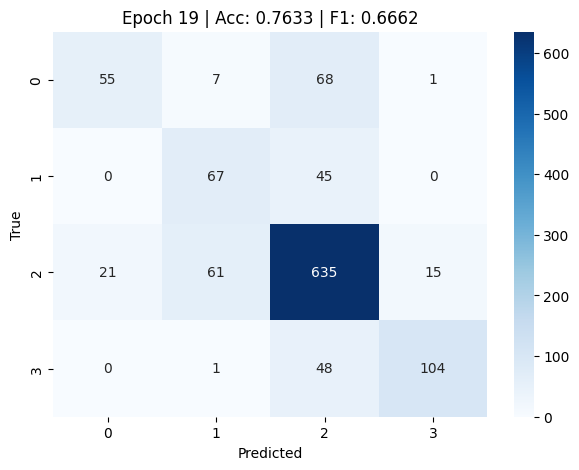

Epoch 19 | Overall Acc: 0.7633 | F1: 0.6662
Class-wise Accuracies:
  Class 0: 0.4198
  Class 1: 0.5982
  Class 2: 0.8675
  Class 3: 0.6797


Epoch 20: 100%|██████████| 75/75 [00:20<00:00,  3.59it/s, loss=0.634] 


Val Acc: 0.7633 | F1: 0.6954 | Dist: Counter({np.int64(2): 680, np.int64(3): 200, np.int64(1): 133, np.int64(0): 115})


Epoch 21: 100%|██████████| 75/75 [00:21<00:00,  3.54it/s, loss=0.617] 


Val Acc: 0.7447 | F1: 0.6908 | Dist: Counter({np.int64(2): 622, np.int64(3): 209, np.int64(0): 167, np.int64(1): 130})


...

Val Acc: 0.7615 | F1: 0.6946 | Dist: Counter({np.int64(2): 712, np.int64(1): 162, np.int64(3): 143, np.int64(0): 111})


Epoch 24: 100%|██████████| 75/75 [00:21<00:00,  3.55it/s, loss=0.604] 


Val Acc: 0.7181 | F1: 0.6758 | Dist: Counter({np.int64(2): 601, np.int64(1): 225, np.int64(0): 152, np.int64(3): 150})


Epoch 25: 100%|██████████| 75/75 [00:20<00:00,  3.58it/s, loss=0.605] 


Val Acc: 0.7775 | F1: 0.6951 | Dist: Counter({np.int64(2): 738, np.int64(3): 194, np.int64(1): 115, np.int64(0): 81})
>>> New Best Model Saved (Acc: 0.7775)


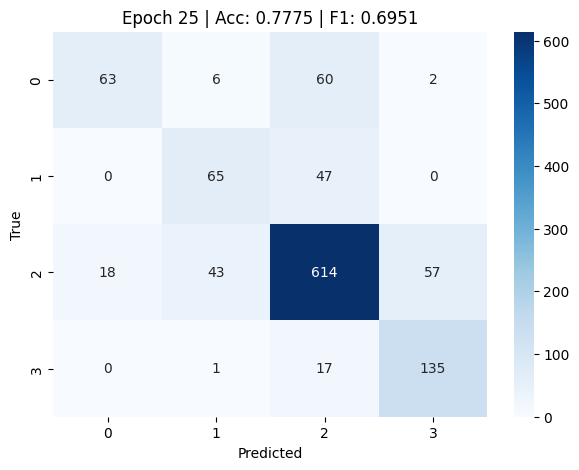

Epoch 25 | Overall Acc: 0.7775 | F1: 0.6951
Class-wise Accuracies:
  Class 0: 0.4809
  Class 1: 0.5804
  Class 2: 0.8388
  Class 3: 0.8824


Epoch 26: 100%|██████████| 75/75 [00:21<00:00,  3.49it/s, loss=0.594] 


Val Acc: 0.7819 | F1: 0.7103 | Dist: Counter({np.int64(2): 714, np.int64(3): 187, np.int64(1): 121, np.int64(0): 106})
>>> New Best Model Saved (Acc: 0.7819)


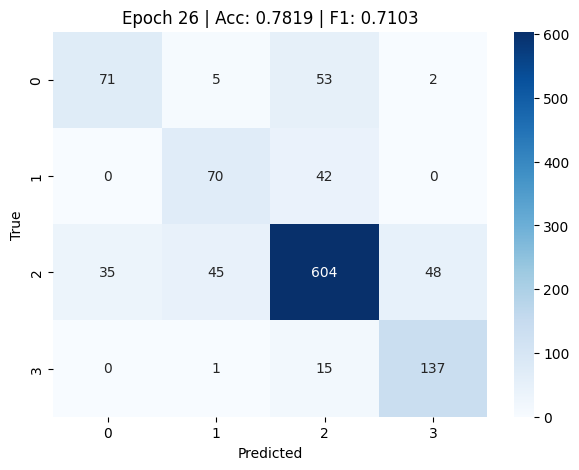

Epoch 26 | Overall Acc: 0.7819 | F1: 0.7103
Class-wise Accuracies:
  Class 0: 0.5420
  Class 1: 0.6250
  Class 2: 0.8251
  Class 3: 0.8954


Epoch 27: 100%|██████████| 75/75 [00:21<00:00,  3.56it/s, loss=0.592] 


Val Acc: 0.7216 | F1: 0.6645 | Dist: Counter({np.int64(2): 605, np.int64(3): 254, np.int64(1): 152, np.int64(0): 117})


Epoch 28: 100%|██████████| 75/75 [00:21<00:00,  3.53it/s, loss=0.59]  


Val Acc: 0.7713 | F1: 0.7023 | Dist: Counter({np.int64(2): 718, np.int64(3): 151, np.int64(1): 136, np.int64(0): 123})


...

Val Acc: 0.7695 | F1: 0.6987 | Dist: Counter({np.int64(2): 719, np.int64(3): 155, np.int64(1): 147, np.int64(0): 107})


Epoch 35: 100%|██████████| 75/75 [00:20<00:00,  3.59it/s, loss=0.568] 


Val Acc: 0.7748 | F1: 0.7090 | Dist: Counter({np.int64(2): 712, np.int64(3): 157, np.int64(0): 141, np.int64(1): 118})


Epoch 36: 100%|██████████| 75/75 [00:20<00:00,  3.58it/s, loss=0.566] 


Val Acc: 0.7917 | F1: 0.7160 | Dist: Counter({np.int64(2): 744, np.int64(3): 171, np.int64(0): 119, np.int64(1): 94})
>>> New Best Model Saved (Acc: 0.7917)


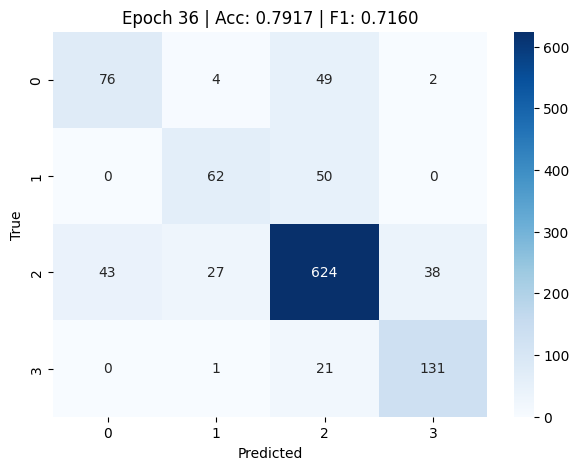

Epoch 36 | Overall Acc: 0.7917 | F1: 0.7160
Class-wise Accuracies:
  Class 0: 0.5802
  Class 1: 0.5536
  Class 2: 0.8525
  Class 3: 0.8562


Epoch 37: 100%|██████████| 75/75 [00:21<00:00,  3.57it/s, loss=0.564] 


Val Acc: 0.7739 | F1: 0.7040 | Dist: Counter({np.int64(2): 709, np.int64(3): 166, np.int64(1): 136, np.int64(0): 117})


Epoch 38: 100%|██████████| 75/75 [00:21<00:00,  3.50it/s, loss=0.563] 


Val Acc: 0.7624 | F1: 0.6996 | Dist: Counter({np.int64(2): 690, np.int64(3): 154, np.int64(1): 152, np.int64(0): 132})


...

Val Acc: 0.7757 | F1: 0.7039 | Dist: Counter({np.int64(2): 728, np.int64(3): 156, np.int64(0): 122, np.int64(1): 122})


Epoch 49: 100%|██████████| 75/75 [00:21<00:00,  3.49it/s, loss=0.56]  


Val Acc: 0.7757 | F1: 0.7013 | Dist: Counter({np.int64(2): 736, np.int64(3): 154, np.int64(0): 120, np.int64(1): 118})


Epoch 50: 100%|██████████| 75/75 [00:21<00:00,  3.54it/s, loss=0.557] 


Val Acc: 0.7748 | F1: 0.6999 | Dist: Counter({np.int64(2): 735, np.int64(3): 159, np.int64(0): 118, np.int64(1): 116})
Final Best Val Accuracy: 0.7917


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import os
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# --- 环境设置 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_dir = os.path.join(os.getcwd(), 'sleep-edf', 'data')
model_save_path = os.path.join(data_dir, 'model', 'model011906.pth')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# --- 参数 ---
batch_size = 128
window_size = 15      # n
lr = 5e-4
num_epochs = 50
num_classes = 4

# --- 1. 核心逻辑：按患者构建时序数据（n-Epoch 窗口）---
def load_context_data(root_path, window_size):
    """
    遍历 patient_data 文件夹，构建 n-Epoch 窗口：(t-n,..., t-1, t, t+1,.., t+n)
    """
    patient_dir = os.path.join(root_path, 'patient_data')
    X_all, y_all = [], []
    
    if not os.path.exists(patient_dir):
        raise FileNotFoundError(f"找不到路径: {patient_dir}")

    x_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('_X.npy')])
    
    print(f"Loading patients from {patient_dir}...")
    half_window = window_size // 2
    for f in tqdm(x_files):
        patient_id = f.replace('_X.npy', '')
        x_sub = np.load(os.path.join(patient_dir, f))
        y_sub = np.load(os.path.join(patient_dir, f"{patient_id}_y.npy"))
        
        # 标签清理与映射
        valid = (y_sub != -1)
        x_sub, y_sub = x_sub[valid], y_sub[valid]
        
        y_mapped = np.zeros_like(y_sub)
        y_mapped[y_sub == 0] = 0  # W
        y_mapped[y_sub == 4] = 1  # REM
        y_mapped[(y_sub == 1) | (y_sub == 2)] = 2  # Light (N1+N2)
        y_mapped[y_sub == 3] = 3  # Deep (N3)
        
        # 构建 5-Epoch 窗口
        for i in range(half_window, len(x_sub) - half_window):
            window = x_sub[i - half_window: i + half_window + 1]  # (n, 3000)
            X_all.append(window)
            y_all.append(y_mapped[i])
            
    return np.array(X_all), np.array(y_all)

# --- 2. 数据集类（增强增广：噪声 + 随机遮罩，移除时间拉伸）---
class SleepContextDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32).float()  # 确保 float
        self.y = torch.tensor(y, dtype=torch.long)
        
        # 全局标准化
        mean, std = self.X.mean(), self.X.std()
        self.X = (self.X - mean) / (std + 1e-6)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        
        if self.augment and x.is_floating_point():
            # 原增强：微小噪声
            if torch.rand(1) < 0.3:
                x = x + torch.randn_like(x) * 0.005
            # 保留：随机遮罩（10% 信号丢失）
            if torch.rand(1) < 0.25:
                mask = torch.rand_like(x) > 0.1  # 适用于 float
                x = x * mask
        
        return x, y

# --- 3. 模型（n通道输入）---
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ELU(),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se = SEBlock(out_ch) # 新增注意力
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        self.elu = nn.ELU()

    def forward(self, x):
        out = self.conv(x)
        out = self.se(out) # 赋予特征通道权重
        return self.elu(out + self.shortcut(x))


class SleepStageNetV8(nn.Module):
    def __init__(self, num_classes, window_size=5):
        super().__init__()
        self.window_size = window_size
        self.n_fft = 512
        self.hop_length = 64
        
        # --- 分支 A: 频谱特征提取 (2D CNN) ---
        self.spec_stem = nn.Sequential(
            nn.Conv2d(1, 32, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU()
        )
        self.spec_stage = nn.Sequential(
            ResBlock(32, 64, stride=2),
            ResBlock(64, 128, stride=2),
            ResBlock(128, 128, stride=2), # 缩减输出通道为128
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        # --- 分支 B: 原始波形特征提取 (1D CNN) ---
        # 模仿 TinySleepNet/DeepSleepNet 的小核+大核思想简化版
        self.raw_branch = nn.Sequential(
            # 第一层使用较大的卷积核捕捉低频节律 (如 Delta 波)
            nn.Conv1d(1, 64, kernel_size=64, stride=8, padding=32, bias=False),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.MaxPool1d(kernel_size=8, stride=8),
            # 第二层捕捉局部细节
            nn.Conv1d(64, 128, kernel_size=16, stride=1, padding=8, bias=False),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.AdaptiveAvgPool1d(1) # 输出维度 (B*T, 128, 1)
        )
        
        # --- 融合与时序层 ---
        # 两个分支各出 128 维，合起来是 256
        self.rnn = nn.GRU(128 + 128, 128, num_layers=2, bidirectional=True, batch_first=True, dropout=0.3)
        
        # 分类器
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: [Batch, n, 1, 3001]
        b, t, c, s = x.shape
        x_flat = x.view(b * t, c, s) # [B*T, 1, 3001]
        
        # --- 1. 频谱分支 (2D) ---
        # 在 forward 内部计算频谱
        win = torch.hann_window(self.n_fft).to(x.device)
        stft = torch.stft(x_flat.squeeze(1), n_fft=self.n_fft, hop_length=self.hop_length, 
                          window=win, return_complex=True, center=True)
        mag = (torch.abs(stft) + 1e-8).log().unsqueeze(1) # [B*T, 1, F, T]
        mag = mag[:, :, :128, :] # 取低频部分
        
        spec_fea = self.spec_stem(mag)
        spec_fea = self.spec_stage(spec_fea).flatten(1) # [B*T, 128]
        
        # --- 2. 原始波形分支 (1D) ---
        raw_fea = self.raw_branch(x_flat).flatten(1) # [B*T, 128]
        
        # --- 3. 特征融合 ---
        combined_fea = torch.cat([spec_fea, raw_fea], dim=1) # [B*T, 256]
        
        # --- 4. 还原序列维度过 RNN ---
        combined_fea = combined_fea.view(b, t, -1) # [B, n, 256]
        rnn_out, _ = self.rnn(combined_fea)  # [B, n, 256]
        
        # --- 5. 取中间 Epoch 输出 ---
        mid_idx = t // 2
        return self.classifier(rnn_out[:, mid_idx, :])



# --- 4. 评估 ---
def evaluate(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x.to(device))
            all_p.extend(outputs.argmax(1).cpu().numpy())
            all_l.extend(y.numpy())
    return accuracy_score(all_l, all_p), f1_score(all_l, all_p, average='macro'), confusion_matrix(all_l, all_p), Counter(all_p)

def print_confusion_matrix(cm, acc, f1, epoch):
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Epoch {epoch} | Acc: {acc:.4f} | F1: {f1:.4f}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
    # 计算每个分类的准确率
    class_accuracies = cm.diagonal() / cm.sum(axis=1)
    print(f"Epoch {epoch} | Overall Acc: {acc:.4f} | F1: {f1:.4f}")
    print("Class-wise Accuracies:")
    for i, class_acc in enumerate(class_accuracies):
        print(f"  Class {i}: {class_acc:.4f}")

# --- 5. 主训练程序 ---
if __name__ == "__main__":
    train_X, train_y = load_context_data(os.path.join(data_dir, 'train', 'cache'), window_size=window_size)
    val_X, val_y = load_context_data(os.path.join(data_dir, 'val', 'cache'), window_size=window_size)
    
    train_loader = DataLoader(SleepContextDataset(train_X, train_y, augment=True), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SleepContextDataset(val_X, val_y), batch_size=batch_size)

    model = SleepStageNetV8(num_classes=num_classes, window_size=window_size).to(device)
    
    # cls_weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
    # cls_weights = torch.tensor(cls_weights, dtype=torch.float32).to(device)
    cls_weights = torch.tensor([3.0, 4.0, 0.5, 1.0]).to(device)
    criterion = nn.CrossEntropyLoss(weight=cls_weights, label_smoothing=0.1)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    best_acc = 0
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=total_loss / len(pbar))
        
        acc, f1, cm, preds_counter = evaluate(model, val_loader)
        print(f"Val Acc: {acc:.4f} | F1: {f1:.4f} | Dist: {preds_counter}")
        
        scheduler.step()
        
        if acc > best_acc and acc > 0.76:
            best_acc = acc
            torch.save(model.state_dict(), model_save_path)
            print(f">>> New Best Model Saved (Acc: {best_acc:.4f})")
            print_confusion_matrix(cm, acc, f1, epoch+1)

    print(f"Final Best Val Accuracy: {best_acc:.4f}")
